Using device: cpu
Loading checkpoint...
✅ Checkpoint loaded successfully!

Configuration:
  Classes: ['ADLs', 'Aggregates', 'Droplets', 'Gels', 'Solution']
  Number of classes: 5
  Image size: (224, 224)

Available models in checkpoint: ['RandomForest', 'SimpleCNN', 'DenseNet', 'ResNet', 'EfficientNet']
✅ RandomForest loaded
✅ SimpleCNN loaded
✅ DenseNet loaded
✅ ResNet loaded
✅ EfficientNet loaded

✅ Successfully loaded 5 models
   Model keys: ['RandomForest', 'SimpleCNN', 'DenseNet', 'ResNet', 'EfficientNet']

RECONSTRUCTING TEST DATA (with texture-focused cropping)
✅ Test data shape: (125, 224, 224)
   Histogram features: (125, 1)
   Labels: (125,)

COMPUTING PROBABILITIES
Computing RandomForest probabilities...
  ✅ Shape: (125, 5)
Computing SimpleCNN probabilities...
  ✅ Shape: (125, 5)
Computing DenseNet probabilities...
  ✅ Shape: (125, 5)
Computing ResNet probabilities...
  ✅ Shape: (125, 5)
Computing EfficientNet probabilities...
  ✅ Shape: (125, 5)

✅ Probabilities computed fo

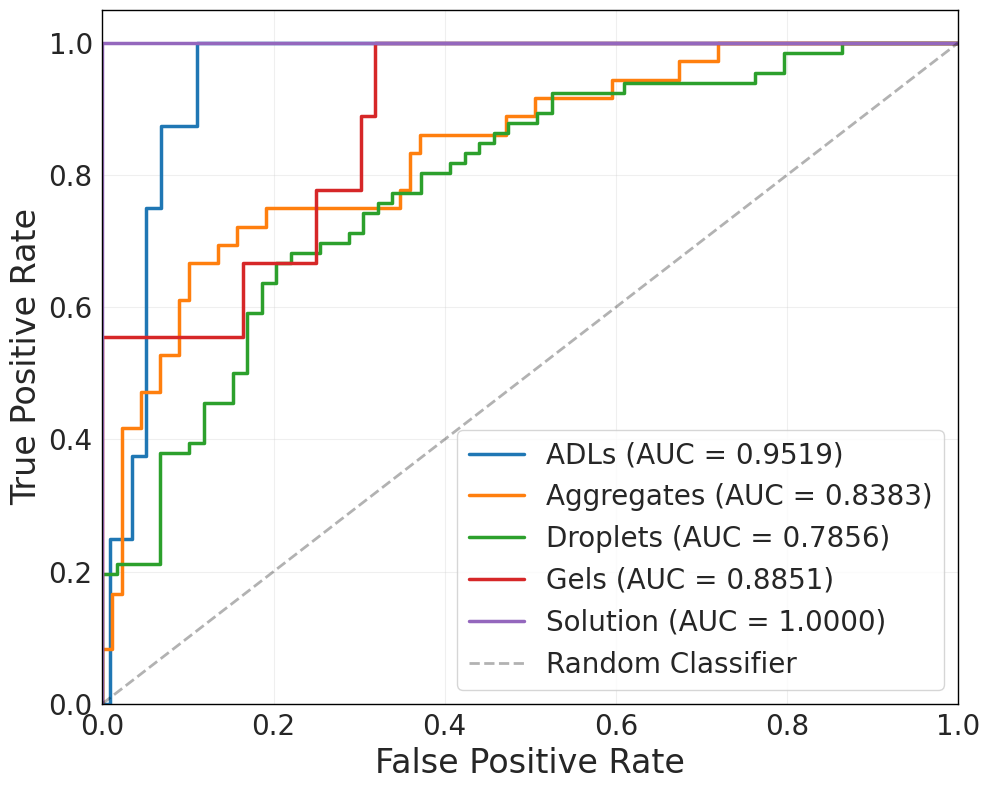

✅ Saved: pr_RandomForest.pdf


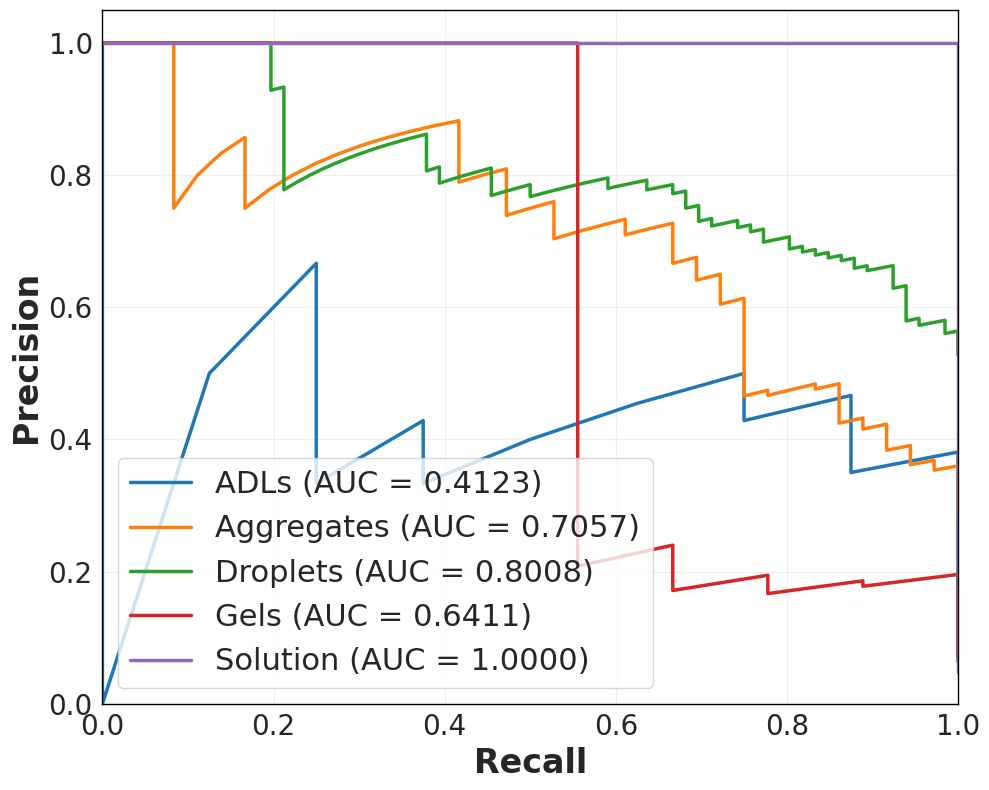

✅ Saved: roc_SimpleCNN.pdf


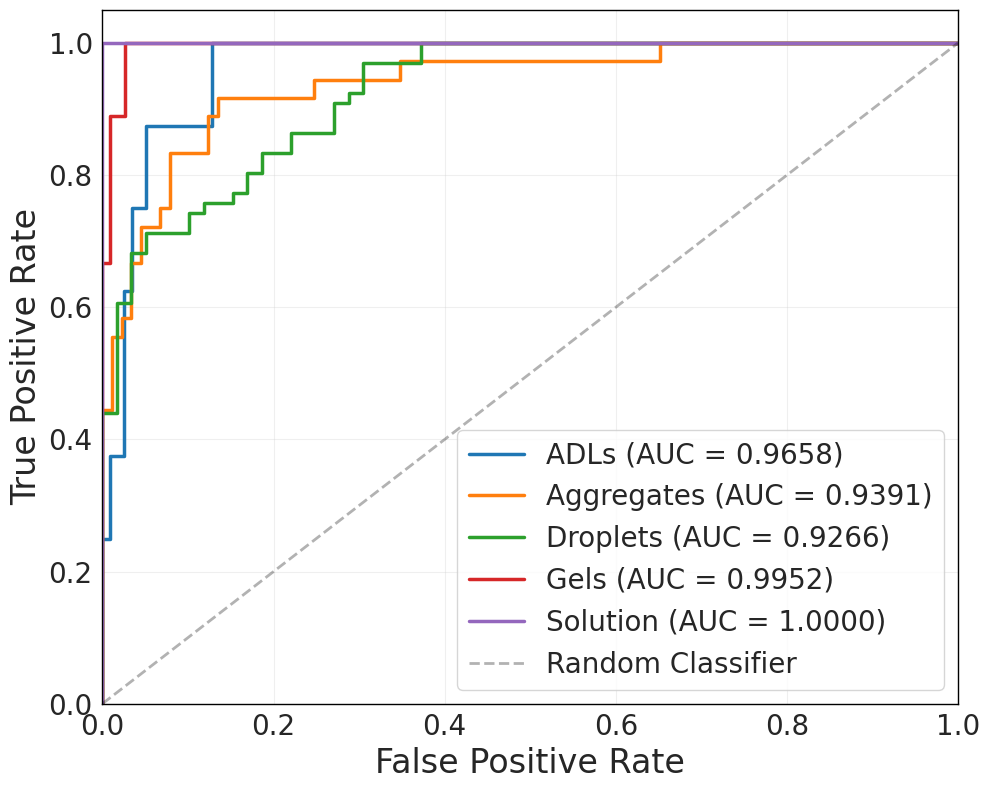

✅ Saved: pr_SimpleCNN.pdf


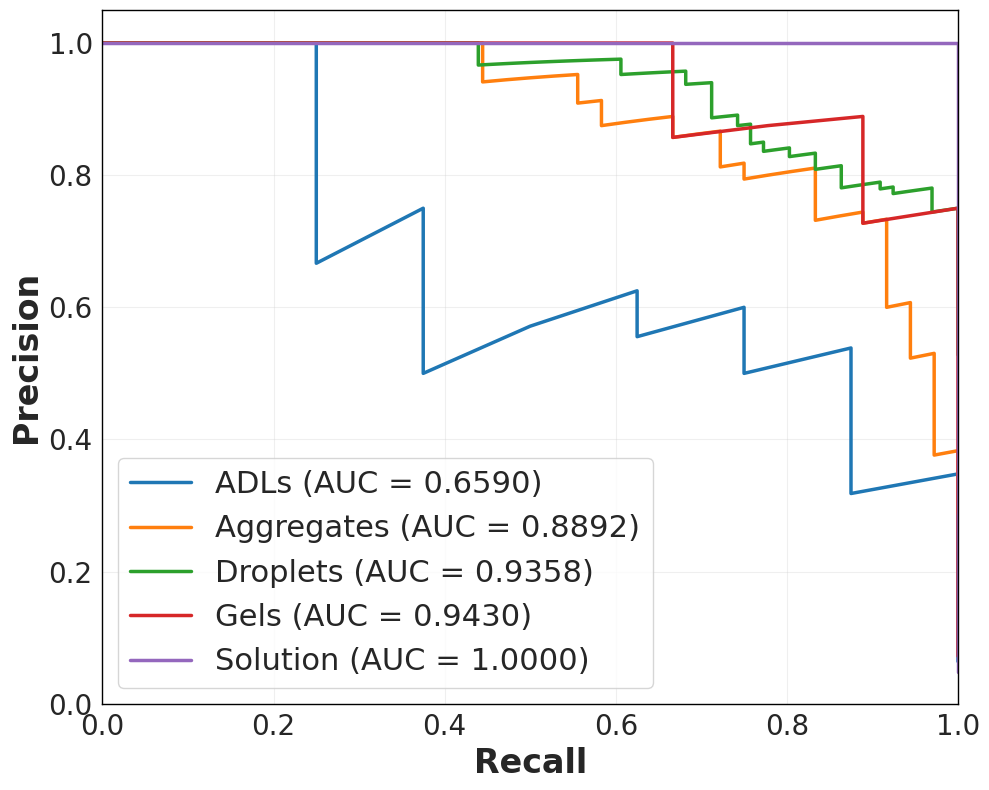

✅ Saved: roc_DenseNet.pdf


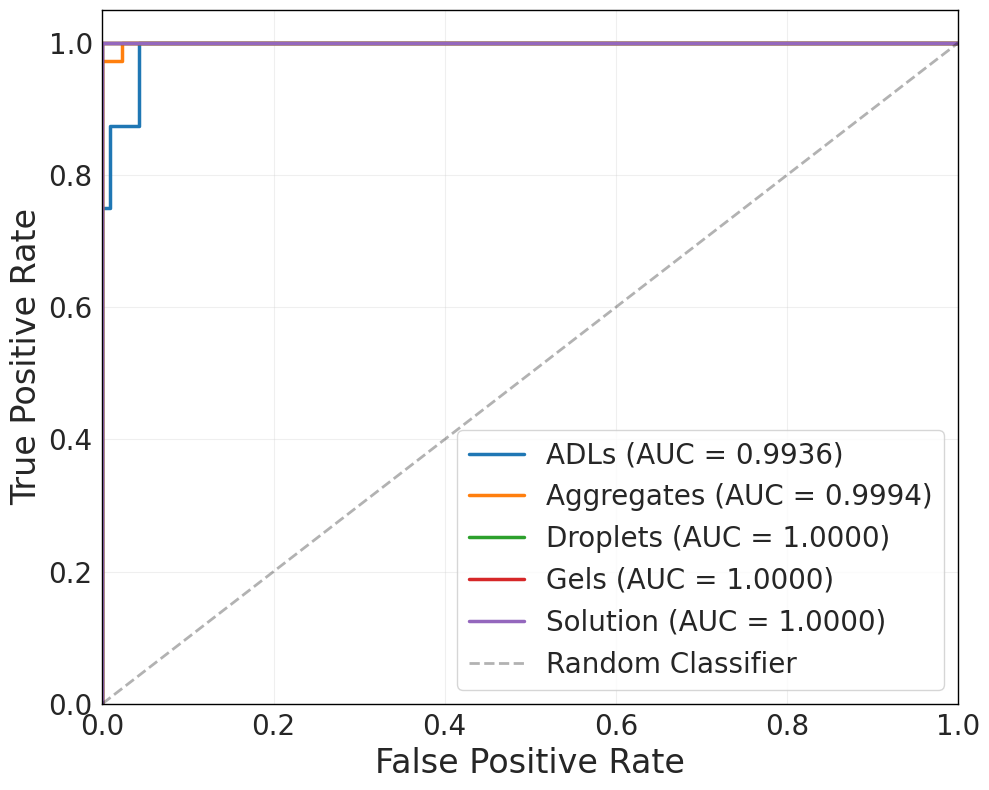

✅ Saved: pr_DenseNet.pdf


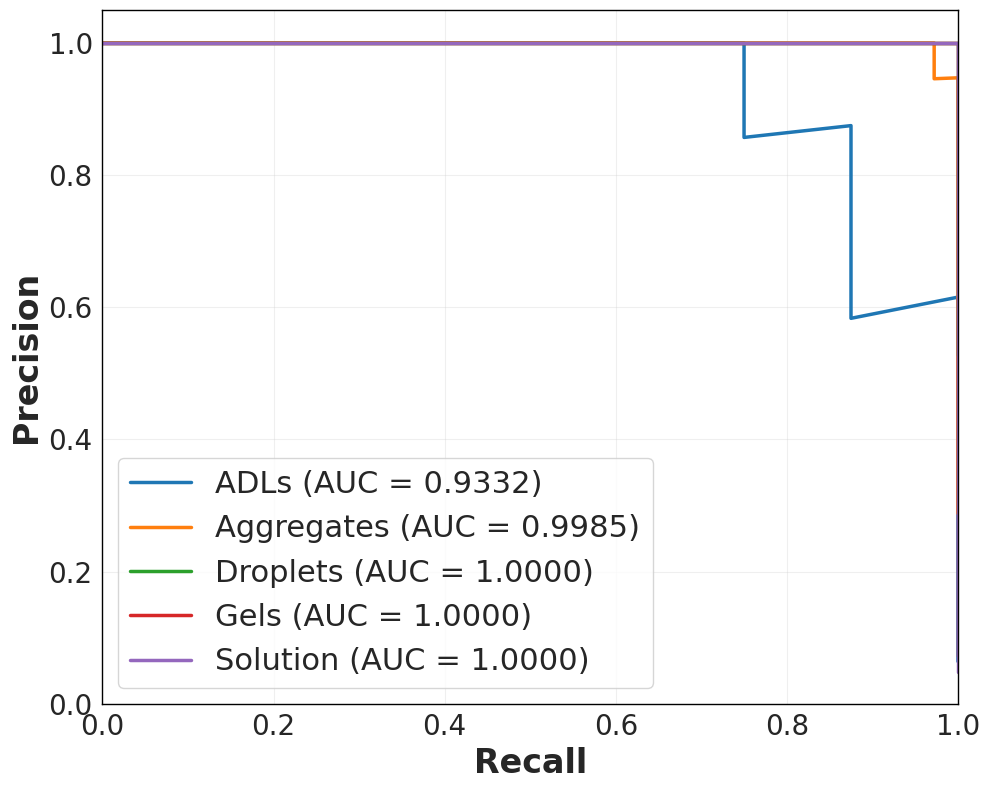

✅ Saved: roc_ResNet.pdf


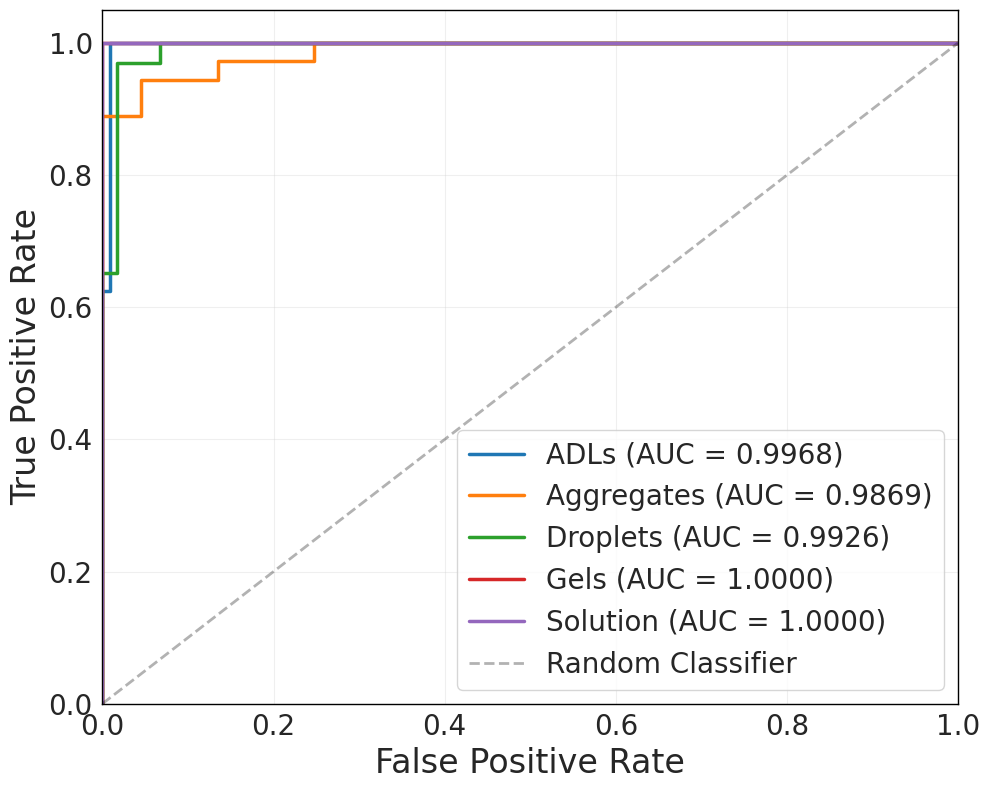

✅ Saved: pr_ResNet.pdf


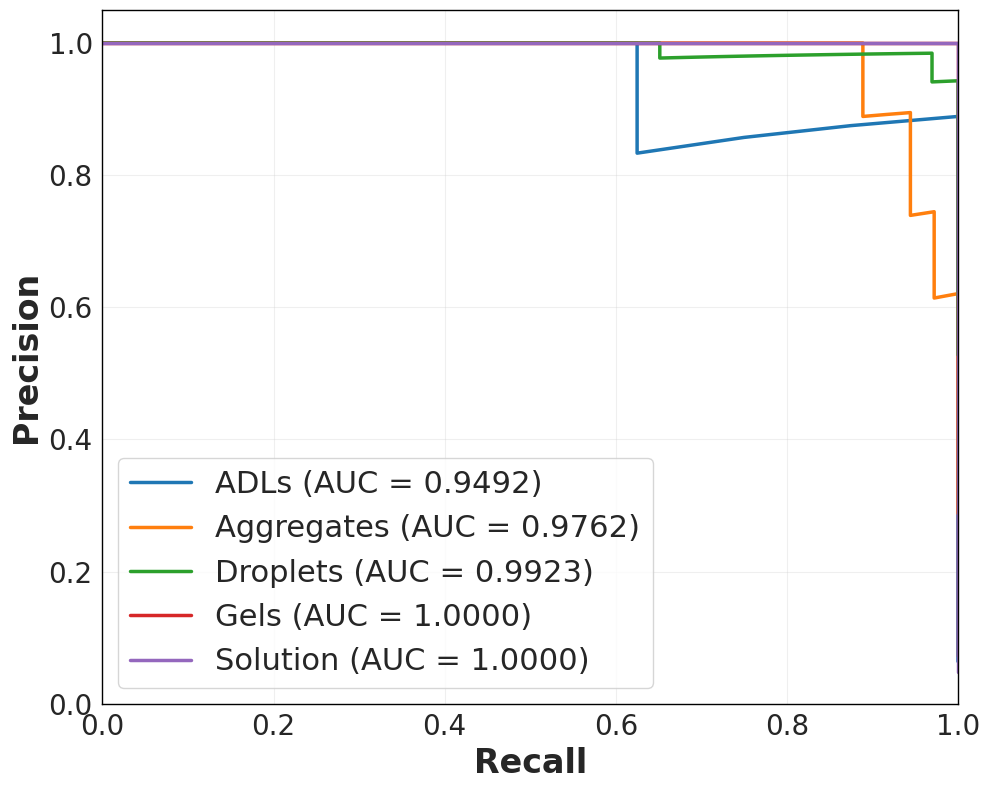

✅ Saved: roc_EfficientNet.pdf


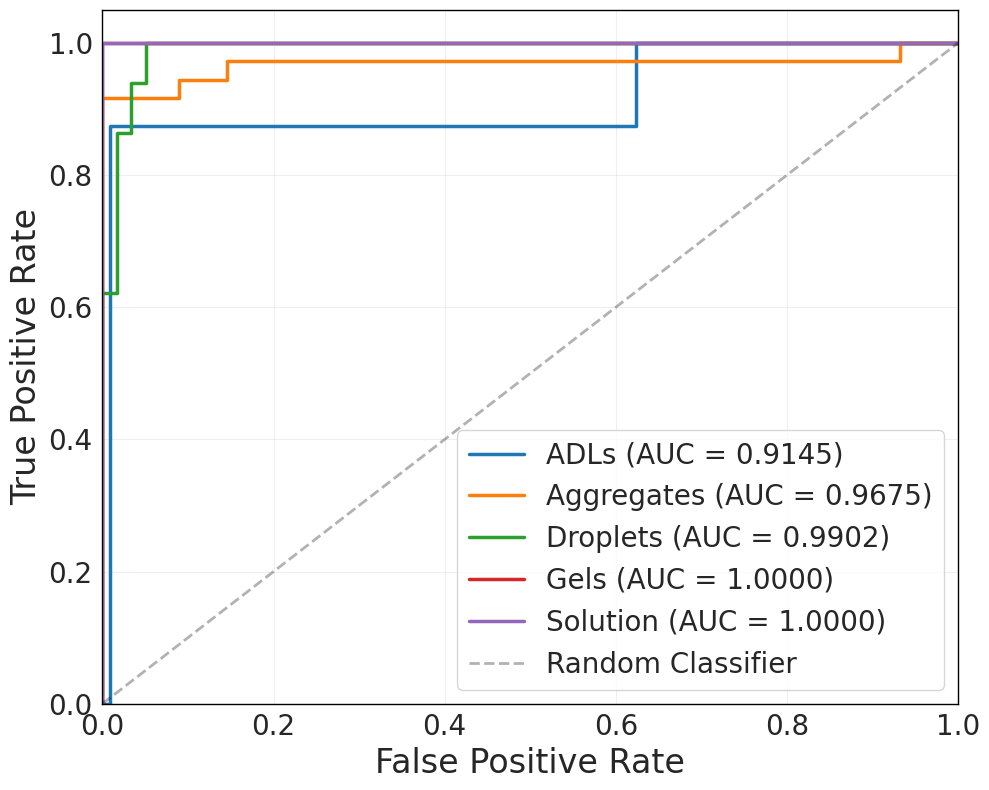

✅ Saved: pr_EfficientNet.pdf


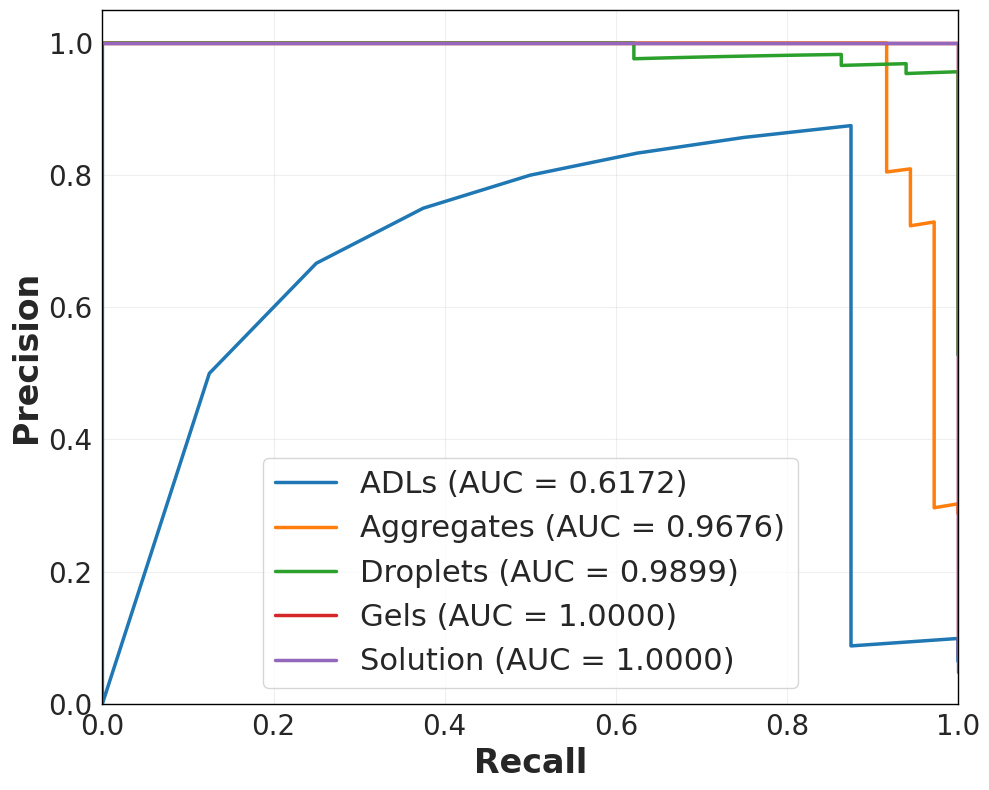


✅ ALL CURVES GENERATED SUCCESSFULLY!

Generated files:
  - roc_RandomForest.pdf
  - pr_RandomForest.pdf
  - roc_SimpleCNN.pdf
  - pr_SimpleCNN.pdf
  - roc_DenseNet.pdf
  - pr_DenseNet.pdf
  - roc_ResNet.pdf
  - pr_ResNet.pdf
  - roc_EfficientNet.pdf
  - pr_EfficientNet.pdf


In [1]:
import pickle
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import roc_curve, auc, precision_recall_curve
from sklearn.preprocessing import label_binarize
import torch
import torch.nn as nn
import torch.nn.functional as F
from torch.utils.data import DataLoader, TensorDataset
import seaborn as sns
import torchvision.models as models
import io
import cv2
from PIL import Image
import os

# ============================================================================
# MODEL CLASS DEFINITIONS (Required for unpickling)
# ============================================================================

class SimpleCNNWithScalar(nn.Module):
    def __init__(self, num_classes=5, img_hw=224, scalar_dim=1, 
                 conv_channels=[16, 32, 64], fc_hidden=256, dropout=0.2):
        super().__init__()
        
        self.conv_layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()
        
        in_channels = 1
        for out_channels in conv_channels:
            self.conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            self.bn_layers.append(nn.BatchNorm2d(out_channels))
            in_channels = out_channels
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout)
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, img_hw, img_hw)
            for conv, bn in zip(self.conv_layers, self.bn_layers):
                dummy = self.pool(F.relu(bn(conv(dummy))))
            flat_img_feats = dummy.view(1, -1).size(1)
        
        self.img_fc = nn.Linear(flat_img_feats, fc_hidden)
        
        self.scalar_mlp = nn.Sequential(
            nn.Linear(scalar_dim, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
        )
        
        self.fuse_fc = nn.Sequential(
            nn.Linear(fc_hidden + 32, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img, x_scalar):
        x = x_img
        for conv, bn in zip(self.conv_layers, self.bn_layers):
            x = self.pool(F.relu(bn(conv(x))))
        
        x = x.view(x.size(0), -1)
        x = F.relu(self.img_fc(x))
        x = self.dropout(x)
        
        s = self.scalar_mlp(x_scalar)
        z = torch.cat([x, s], dim=1)
        logits = self.fuse_fc(z)
        return logits


class DenseNet121WithScalar(nn.Module):
    def __init__(self, num_classes=5, scalar_dim=1, dropout=0.4, fc_hidden=256):
        super().__init__()
        backbone = models.densenet121(pretrained=False)
        
        old_conv = backbone.features.conv0
        new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride, padding=old_conv.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.features.conv0 = new_conv
        
        self.features = backbone.features
        self.num_ftrs = backbone.classifier.in_features
        
        self.img_fc = nn.Sequential(
            nn.Linear(self.num_ftrs, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        
        self.scalar_mlp = nn.Sequential(
            nn.Linear(scalar_dim, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(fc_hidden + 32, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img, x_scalar):
        x = self.features(x_img)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        x = self.img_fc(x)
        
        s = self.scalar_mlp(x_scalar)
        z = torch.cat([x, s], dim=1)
        logits = self.classifier(z)
        return logits


class ResNet18WithScalar(nn.Module):
    def __init__(self, num_classes=5, scalar_dim=1, dropout=0.4, fc_hidden=256, pretrained=True):
        super().__init__()
        backbone = models.resnet18(pretrained=False)
        
        old = backbone.conv1
        new = nn.Conv2d(1, old.out_channels, kernel_size=old.kernel_size,
                        stride=old.stride, padding=old.padding, bias=False)
        with torch.no_grad():
            new.weight.copy_(old.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = new
        
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu,
            backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
        )
        self.avgpool = backbone.avgpool
        self.backbone_out = backbone.fc.in_features
        
        self.img_fc = nn.Sequential(
            nn.Linear(self.backbone_out, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        
        self.scalar_mlp = nn.Sequential(
            nn.Linear(scalar_dim, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(fc_hidden + 32, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img, x_scalar):
        x = self.backbone(x_img)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.img_fc(x)
        
        s = self.scalar_mlp(x_scalar)
        z = torch.cat([x, s], dim=1)
        logits = self.classifier(z)
        return logits


class EfficientNetB0WithScalar(nn.Module):
    def __init__(self, num_classes=5, scalar_dim=1, dropout=0.4, fc_hidden=256, use_weights=True):
        super().__init__()
        
        backbone = models.efficientnet_b0(pretrained=False)
        
        old_conv = backbone.features[0][0]
        new_conv = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.features[0][0] = new_conv
        
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        self.num_ftrs = backbone.classifier[1].in_features
        
        self.img_fc = nn.Sequential(
            nn.Linear(self.num_ftrs, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
        )
        
        self.scalar_mlp = nn.Sequential(
            nn.Linear(scalar_dim, 32),
            nn.ReLU(inplace=True),
            nn.Linear(32, 32),
            nn.ReLU(inplace=True),
        )
        
        self.classifier = nn.Sequential(
            nn.Linear(fc_hidden + 32, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img, x_scalar):
        x = self.features(x_img)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        x = self.img_fc(x)
        
        s = self.scalar_mlp(x_scalar)
        z = torch.cat([x, s], dim=1)
        return self.classifier(z)

# ============================================================================
# ORIGINAL MODEL CLASS DEFINITIONS (Required for unpickling checkpoint)
# ============================================================================

class SimpleCNN(nn.Module):
    def __init__(self, num_classes=5, img_hw=224, 
                 conv_channels=[16, 32, 64], fc_hidden=256, dropout=0.2):
        super().__init__()
        
        self.conv_layers = nn.ModuleList()
        self.bn_layers = nn.ModuleList()
        
        in_channels = 1
        for out_channels in conv_channels:
            self.conv_layers.append(nn.Conv2d(in_channels, out_channels, kernel_size=3, padding=1))
            self.bn_layers.append(nn.BatchNorm2d(out_channels))
            in_channels = out_channels
        
        self.pool = nn.MaxPool2d(2, 2)
        self.dropout = nn.Dropout(dropout)
        
        with torch.no_grad():
            dummy = torch.zeros(1, 1, img_hw, img_hw)
            for conv, bn in zip(self.conv_layers, self.bn_layers):
                dummy = self.pool(F.relu(bn(conv(dummy))))
            flat_img_feats = dummy.view(1, -1).size(1)
        
        self.classifier = nn.Sequential(
            nn.Linear(flat_img_feats, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img):
        x = x_img
        for conv, bn in zip(self.conv_layers, self.bn_layers):
            x = self.pool(F.relu(bn(conv(x))))
        
        x = x.view(x.size(0), -1)
        logits = self.classifier(x)
        return logits


class DenseNet121(nn.Module):
    def __init__(self, num_classes=5, dropout=0.4, fc_hidden=256):
        super().__init__()
        backbone = models.densenet121(pretrained=False)
        
        old_conv = backbone.features.conv0
        new_conv = nn.Conv2d(1, old_conv.out_channels, kernel_size=old_conv.kernel_size,
                             stride=old_conv.stride, padding=old_conv.padding, bias=False)
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.features.conv0 = new_conv
        
        self.features = backbone.features
        self.num_ftrs = backbone.classifier.in_features
        
        self.classifier = nn.Sequential(
            nn.Linear(self.num_ftrs, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img):
        x = self.features(x_img)
        x = F.relu(x, inplace=True)
        x = F.adaptive_avg_pool2d(x, (1, 1))
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits


class ResNet18(nn.Module):
    def __init__(self, num_classes=5, dropout=0.4, fc_hidden=256, pretrained=True):
        super().__init__()
        backbone = models.resnet18(pretrained=False)
        
        old = backbone.conv1
        new = nn.Conv2d(1, old.out_channels, kernel_size=old.kernel_size,
                        stride=old.stride, padding=old.padding, bias=False)
        with torch.no_grad():
            new.weight.copy_(old.weight.mean(dim=1, keepdim=True))
        backbone.conv1 = new
        
        self.backbone = nn.Sequential(
            backbone.conv1, backbone.bn1, backbone.relu,
            backbone.maxpool,
            backbone.layer1, backbone.layer2, backbone.layer3, backbone.layer4,
        )
        self.avgpool = backbone.avgpool
        self.backbone_out = backbone.fc.in_features
        
        self.classifier = nn.Sequential(
            nn.Linear(self.backbone_out, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img):
        x = self.backbone(x_img)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        logits = self.classifier(x)
        return logits


class EfficientNetB0(nn.Module):
    def __init__(self, num_classes=5, dropout=0.4, fc_hidden=256, use_weights=True):
        super().__init__()
        
        backbone = models.efficientnet_b0(pretrained=False)
        
        old_conv = backbone.features[0][0]
        new_conv = nn.Conv2d(
            1, old_conv.out_channels,
            kernel_size=old_conv.kernel_size,
            stride=old_conv.stride,
            padding=old_conv.padding,
            bias=False
        )
        with torch.no_grad():
            new_conv.weight.copy_(old_conv.weight.mean(dim=1, keepdim=True))
        backbone.features[0][0] = new_conv
        
        self.features = backbone.features
        self.avgpool = backbone.avgpool
        self.num_ftrs = backbone.classifier[1].in_features
        
        self.classifier = nn.Sequential(
            nn.Linear(self.num_ftrs, fc_hidden),
            nn.ReLU(inplace=True),
            nn.Dropout(dropout),
            nn.Linear(fc_hidden, num_classes),
        )
    
    def forward(self, x_img):
        x = self.features(x_img)
        x = self.avgpool(x)
        x = torch.flatten(x, 1)
        return self.classifier(x)


# ============================================================================
# CUSTOM UNPICKLER FOR CPU MAPPING
# ============================================================================



class CPU_Unpickler(pickle.Unpickler):
    """Custom unpickler that forces all tensors to CPU"""
    def find_class(self, module, name):
        if module == 'torch.storage' and name == '_load_from_bytes':
            return lambda b: torch.load(io.BytesIO(b), map_location='cpu')
        else:
            return super().find_class(module, name)

# ============================================================================
# ✅ FIXED: IMAGE PROCESSING WITH TEXTURE-FOCUSED CROPPING
# ============================================================================



def load_and_preprocess_image(img_path, img_size=(224, 224)):
    """
    ✅ FIXED: Load and preprocess image EXACTLY as done in training
    Including texture-focused cropping!
    """
    try:
        # Load image
        pil_img = Image.open(img_path)
        gray = np.array(pil_img, dtype=np.uint8)
        
        # Histogram feature (sum of pixel intensities)
        hist_feat = float(np.sum(gray))
        
       
        
        cropped = pil_img.convert('L')
        cropped = cropped.resize(img_size)
        cropped = np.array(cropped, dtype=np.uint8)
        

               
        norm_clahe = cropped.astype(np.float32)
        norm_post = norm_clahe.astype(np.float32) / 255.0
        
        return norm_post, hist_feat
    
    except Exception as e:
        print(f"Error loading {img_path}: {e}")
        return np.zeros(img_size, dtype=np.float32), 0.0

# ============================================================================
# MAIN CODE
# ============================================================================

device = torch.device('cpu')
print(f"Using device: {device}")

# Load the saved checkpoint
print("Loading checkpoint...")
with open("complete_checkpoint_optuna_optimized.pkl", "rb") as f:
    checkpoint = CPU_Unpickler(f).load()
print("✅ Checkpoint loaded successfully!")

# Extract configuration
config = checkpoint.get('config', {})
CLASS_NAMES = config.get('CLASS_NAMES', ['ADLs', 'Aggregates', 'Droplets', 'Gels', 'Solutions'])


DISPLAY_NAME_MAP = {"Solutions": "Solution"}  # extend here if you want more renames
CLASS_NAMES = [DISPLAY_NAME_MAP.get(n, n) for n in CLASS_NAMES]



NUM_CLASSES = len(CLASS_NAMES)
IMG_SIZE = config.get('IMG_SIZE', (224, 224))

print(f"\nConfiguration:")
print(f"  Classes: {CLASS_NAMES}")
print(f"  Number of classes: {NUM_CLASSES}")
print(f"  Image size: {IMG_SIZE}")

# Extract components
le = checkpoint['label_encoder']
scaler = checkpoint['scaler']
test_paths = checkpoint.get('test_paths', [])
final_results = checkpoint.get('final_results', {})

print(f"\nAvailable models in checkpoint: {list(final_results.keys())}")

# ============================================================================
# LOAD MODELS WITH CORRECT NAMING
# ============================================================================

def prepare_model(model, model_name):
    """Unwrap DataParallel and move model to CPU"""
    try:
        if hasattr(model, 'module'):
            model = model.module
        model = model.to(device)
        model.eval()
        print(f"✅ {model_name} loaded")
        return model
    except Exception as e:
        print(f"❌ Error preparing {model_name}: {e}")
        return None

available_models = {}

# Load Random Forest
if 'RandomForest' in final_results and 'model' in final_results['RandomForest']:
    rf_model = final_results['RandomForest']['model']
    if rf_model is not None:
        available_models['RandomForest'] = rf_model
        print("✅ RandomForest loaded")

# Load neural network models
model_mapping = {
    'SimpleCNN': 'SimpleCNN',
    'DenseNet': 'DenseNet',
    'ResNet': 'ResNet', 
    'EfficientNet': 'EfficientNet'
}

for checkpoint_key, display_key in model_mapping.items():
    if checkpoint_key in final_results and 'model' in final_results[checkpoint_key]:
        model = final_results[checkpoint_key]['model']
        if model is not None:
            prepared = prepare_model(model, display_key)
            if prepared is not None:
                available_models[display_key] = prepared

print(f"\n✅ Successfully loaded {len(available_models)} models")
print(f"   Model keys: {list(available_models.keys())}")

# ============================================================================
# ✅ RECONSTRUCT TEST DATA WITH CORRECT PREPROCESSING
# ============================================================================

print("\n" + "="*60)
print("RECONSTRUCTING TEST DATA (with texture-focused cropping)")
print("="*60)

X_test = []
X_hist_test = []
y_test = []

for img_path in test_paths:
    # ✅ Now uses correct preprocessing with texture-focused cropping
    img, hist_feat = load_and_preprocess_image(img_path, IMG_SIZE)
    
    # Extract true label
    class_name = os.path.basename(os.path.dirname(img_path))
    label = le.transform([class_name])[0]
    
    X_test.append(img)
    X_hist_test.append(hist_feat)
    y_test.append(label)

# Convert to arrays
X_test = np.array(X_test, dtype=np.float32)
X_hist_test = np.array(X_hist_test, dtype=np.float32).reshape(-1, 1)
y_test = np.array(y_test, dtype=np.int64)

print(f"✅ Test data shape: {X_test.shape}")
print(f"   Histogram features: {X_hist_test.shape}")
print(f"   Labels: {y_test.shape}")

# ============================================================================
# PREPARE DATA FOR MODELS
# ============================================================================

# For Random Forest
# For Random Forest (auto-match training feature count)
X_test_flat = X_test.reshape(X_test.shape[0], -1)
X_test_scaled = scaler.transform(X_test_flat)

rf_in = None
if 'RandomForest' in available_models:
    rf_expected = available_models['RandomForest'].n_features_in_
    only_pixels = X_test_scaled.shape[1]
    pixels_plus_hist = X_test_scaled.shape[1] + X_hist_test.shape[1]

    if rf_expected == only_pixels:
        # RF was trained on pixels only
        rf_in = X_test_scaled
    elif rf_expected == pixels_plus_hist:
        # RF was trained on pixels + hist (unscaled hist was common)
        rf_in = np.hstack([X_test_scaled, X_hist_test])
    else:
        raise ValueError(
            f"RandomForest expects {rf_expected} features, "
            f"but we can provide {only_pixels} (pixels) or {pixels_plus_hist} (pixels+hist). "
            f"Check how the RF was trained."
        )


# For neural networks
X_test_tensor = torch.from_numpy(X_test).unsqueeze(1).float()
X_hist_test_tensor = torch.from_numpy(X_hist_test).float()
y_test_tensor = torch.from_numpy(y_test).long()

test_dataset = TensorDataset(X_test_tensor, X_hist_test_tensor, y_test_tensor)
test_loader = DataLoader(test_dataset, batch_size=8, shuffle=False)

# ============================================================================
# GET PROBABILITIES FROM ALL MODELS 
# ============================================================================

def get_nn_probabilities(model, test_loader, device):
    """Get probability predictions from neural network (works with 1- or 2-input models)."""
    model.eval()
    all_probs = []
    with torch.no_grad():
        for X_img, X_hist, _ in test_loader:
            X_img = X_img.to(device)
            X_hist = X_hist.to(device)
            try:
                # Try two-input (image + scalar) models
                outputs = model(X_img, X_hist)
            except TypeError:
                # Fall back to single-input (image-only) models
                outputs = model(X_img)
            probs = F.softmax(outputs, dim=1).cpu().numpy()
            all_probs.append(probs)
    return np.vstack(all_probs)


print("\n" + "="*60)
print("COMPUTING PROBABILITIES")
print("="*60)

model_probs = {}

# RandomForest
if 'RandomForest' in available_models:
    print("Computing RandomForest probabilities...")
    probs = available_models['RandomForest'].predict_proba(rf_in)

    model_probs['RandomForest'] = probs
    print(f"  ✅ Shape: {probs.shape}")

# Neural networks
for model_key in ['SimpleCNN', 'DenseNet', 'ResNet', 'EfficientNet']:
    if model_key in available_models:
        print(f"Computing {model_key} probabilities...")
        probs = get_nn_probabilities(available_models[model_key], test_loader, device)
        model_probs[model_key] = probs
        print(f"  ✅ Shape: {probs.shape}")

print(f"\n✅ Probabilities computed for: {list(model_probs.keys())}")

# ============================================================================
# GENERATE ROC AND PR CURVES
# ============================================================================

# Binarize labels for multi-class ROC
y_test_binarized = label_binarize(y_test, classes=range(NUM_CLASSES))

print("\n" + "="*60)
print("GENERATING ROC AND PRECISION-RECALL CURVES")
print("="*60)

# Set style
sns.set_style("whitegrid")
plt.rcParams['figure.dpi'] = 100

for model_name, y_score in model_probs.items():
    
    # ========================
    # ROC CURVE
    # ========================
    plt.figure(figsize=(10, 8))
    
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#9467bd']
    
    for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
        fpr, tpr, _ = roc_curve(y_test_binarized[:, i], y_score[:, i])
        roc_auc = auc(fpr, tpr)
        plt.plot(fpr, tpr, lw=2.5, color=color,
                label=f"{class_name} (AUC = {roc_auc:.4f})")
    
    plt.plot([0, 1], [0, 1], 'k--', lw=2, alpha=0.3, label='Random Classifier')
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('False Positive Rate', fontsize=24 )
    plt.ylabel('True Positive Rate', fontsize=24 )
  #  plt.title(f'ROC Curve - {model_name}', fontsize=16, fontweight='bold')
    plt.legend(loc='lower right', fontsize=20)
    plt.tick_params(axis='both', labelsize=20)  
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')
    


    
    plt.grid(True, alpha=0.3)
    plt.tight_layout()
    
    filename = f"roc_{model_name}.pdf"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"✅ Saved: {filename}")
    plt.show()
    
    # ========================
    # PRECISION-RECALL CURVE
    # ========================
    plt.figure(figsize=(10, 8))
    
    for i, (class_name, color) in enumerate(zip(CLASS_NAMES, colors)):
        precision, recall, _ = precision_recall_curve(
            y_test_binarized[:, i], y_score[:, i])
        pr_auc = auc(recall, precision)
        plt.plot(recall, precision, lw=2.5, color=color,
                label=f"{class_name} (AUC = {pr_auc:.4f})")
    
    plt.xlim([0.0, 1.0])
    plt.ylim([0.0, 1.05])
    plt.xlabel('Recall', fontsize=24, fontweight='bold')
    plt.ylabel('Precision', fontsize=24, fontweight='bold')
   # plt.title(f'Precision-Recall Curve - {model_name}', fontsize=16, fontweight='bold')
    plt.legend(loc='best', fontsize=22)
    plt.grid(True, alpha=0.3)
    plt.tick_params(axis='both', labelsize=20)  
    ax = plt.gca()
    for spine in ax.spines.values():
        spine.set_linewidth(1)
        spine.set_edgecolor('black')

    plt.tight_layout()
    
    filename = f"pr_{model_name}.pdf"
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    print(f"✅ Saved: {filename}")
    plt.show()

print("\n" + "="*60)
print("✅ ALL CURVES GENERATED SUCCESSFULLY!")
print("="*60)
print("\nGenerated files:")
for model_name in model_probs.keys():
    print(f"  - roc_{model_name}.pdf")
    print(f"  - pr_{model_name}.pdf")

GENERATING CONFUSION MATRICES

Processing RandomForest...
  ✅ Got predictions for RandomForest (shape: (125,))

Processing SimpleCNN...
  ✅ Got predictions for SimpleCNN (shape: (125,))

Processing DenseNet...
  ✅ Got predictions for DenseNet (shape: (125,))

Processing ResNet...
  ✅ Got predictions for ResNet (shape: (125,))

Processing EfficientNet...
  ✅ Got predictions for EfficientNet (shape: (125,))

Total models with predictions: 5
Models: ['RandomForest', 'SimpleCNN', 'DenseNet', 'ResNet', 'EfficientNet']

✅ RandomForest: 125 predictions match test size
✅ SimpleCNN: 125 predictions match test size
✅ DenseNet: 125 predictions match test size
✅ ResNet: 125 predictions match test size
✅ EfficientNet: 125 predictions match test size

Class labels: ['ADLs', 'Aggregates', 'Droplets', 'Gels', 'Solution']
Number of classes: 5

Creating confusion matrix for RandomForest...
  Overall Accuracy: 0.6560
  Per-class Accuracy:
    ADLs: 0.2500
    Aggregates: 0.7222
    Droplets: 0.6515
    G

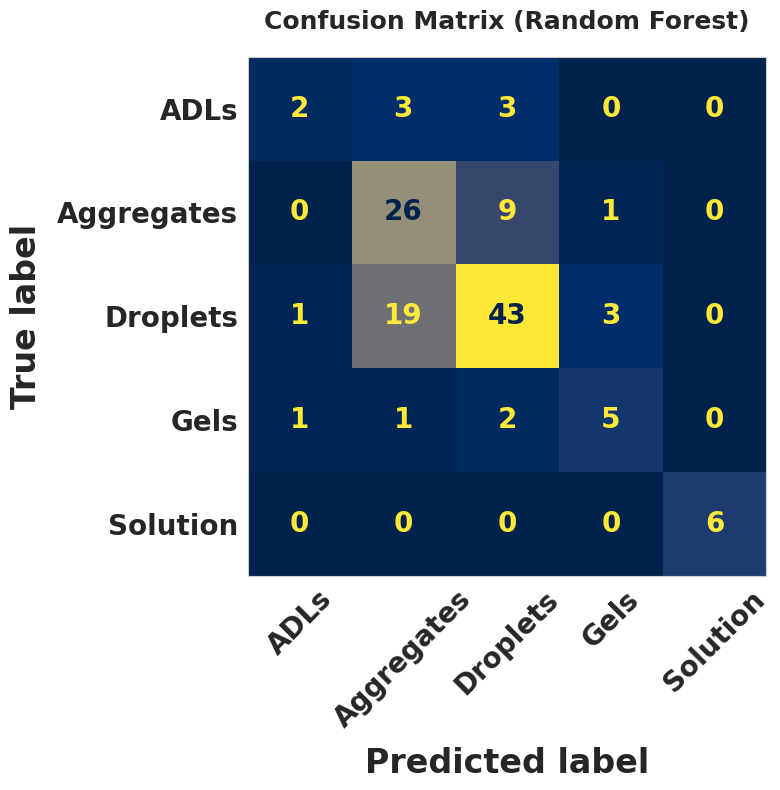

  ✅ Saved: cm_RandomForest.pdf

Creating confusion matrix for SimpleCNN...
  Overall Accuracy: 0.8240
  Per-class Accuracy:
    ADLs: 0.8750
    Aggregates: 0.7222
    Droplets: 0.8636
    Gels: 0.7778
    Solution: 1.0000


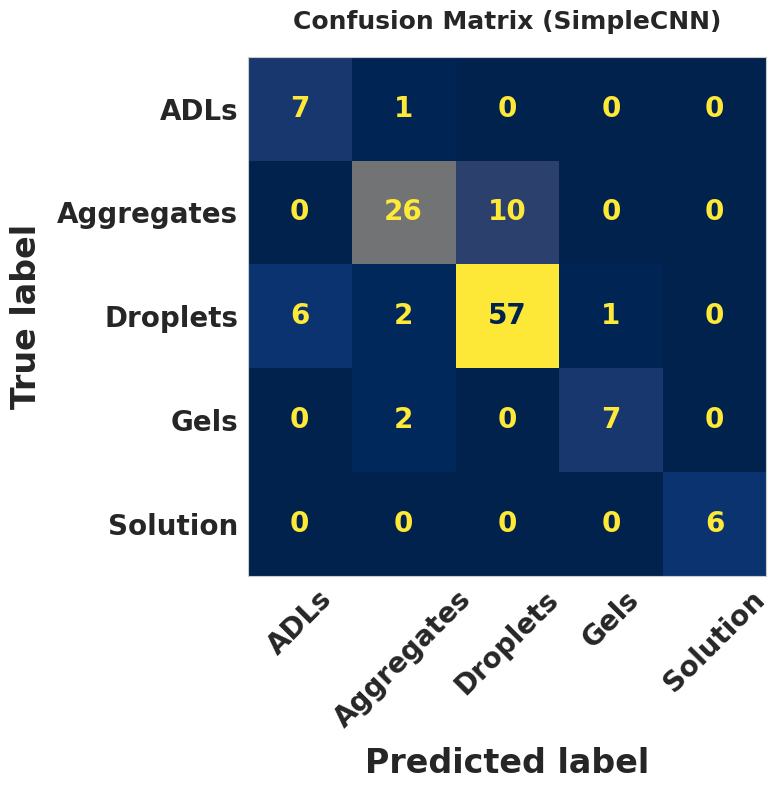

  ✅ Saved: cm_SimpleCNN.pdf

Creating confusion matrix for DenseNet...
  Overall Accuracy: 0.9760
  Per-class Accuracy:
    ADLs: 0.8750
    Aggregates: 0.9444
    Droplets: 1.0000
    Gels: 1.0000
    Solution: 1.0000


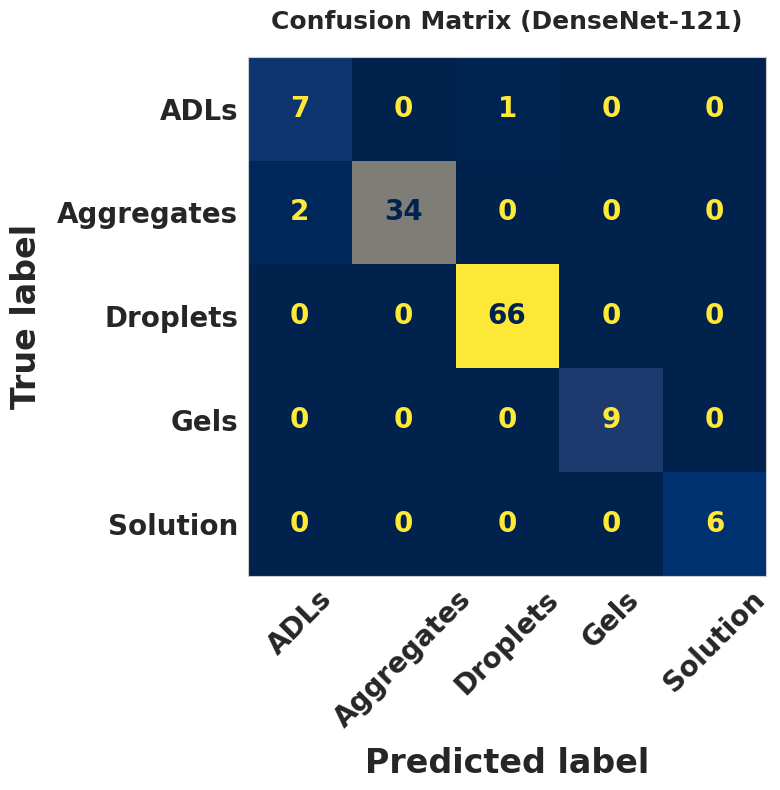

  ✅ Saved: cm_DenseNet.pdf

Creating confusion matrix for ResNet...
  Overall Accuracy: 0.9600
  Per-class Accuracy:
    ADLs: 1.0000
    Aggregates: 0.8889
    Droplets: 1.0000
    Gels: 0.8889
    Solution: 1.0000


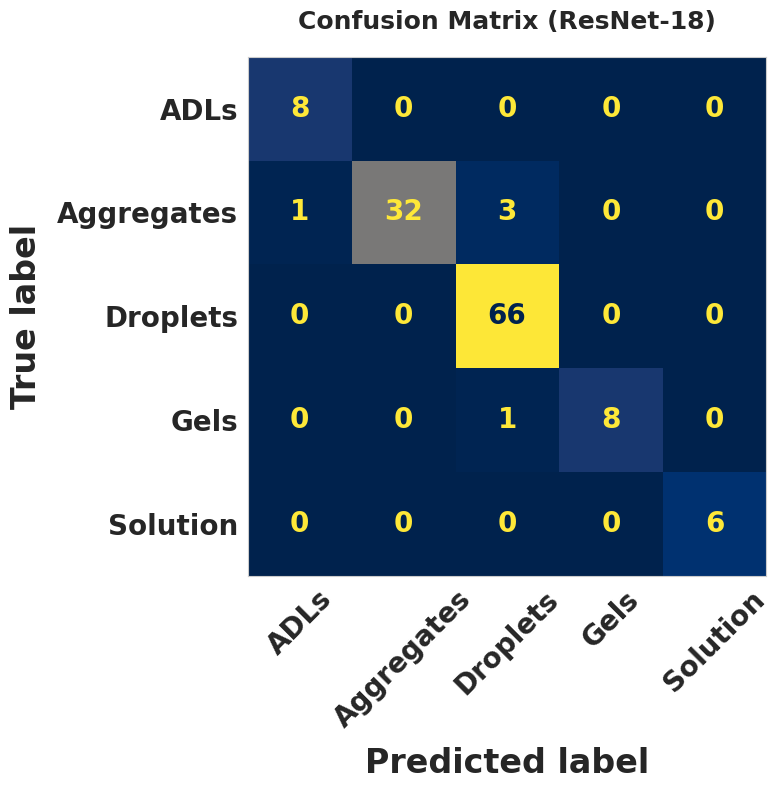

  ✅ Saved: cm_ResNet.pdf

Creating confusion matrix for EfficientNet...
  Overall Accuracy: 0.9680
  Per-class Accuracy:
    ADLs: 0.8750
    Aggregates: 0.9167
    Droplets: 1.0000
    Gels: 1.0000
    Solution: 1.0000


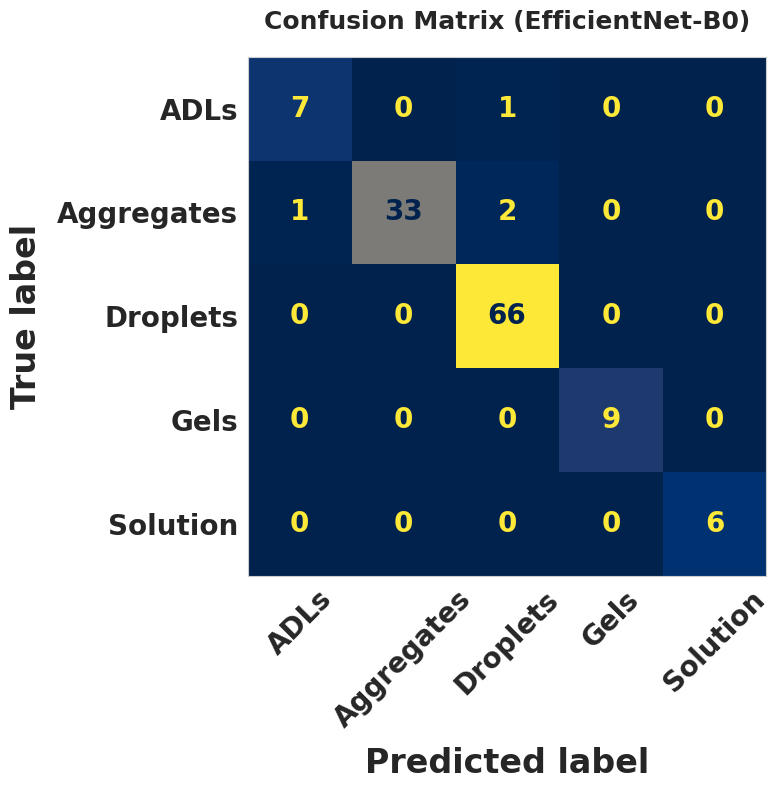

  ✅ Saved: cm_EfficientNet.pdf

✅ CONFUSION MATRIX GENERATION COMPLETE

📁 Saved 5 confusion matrix files:
   - cm_RandomForest.pdf
   - cm_SimpleCNN.pdf
   - cm_DenseNet.pdf
   - cm_ResNet.pdf
   - cm_EfficientNet.pdf

Creating combined confusion matrix comparison...


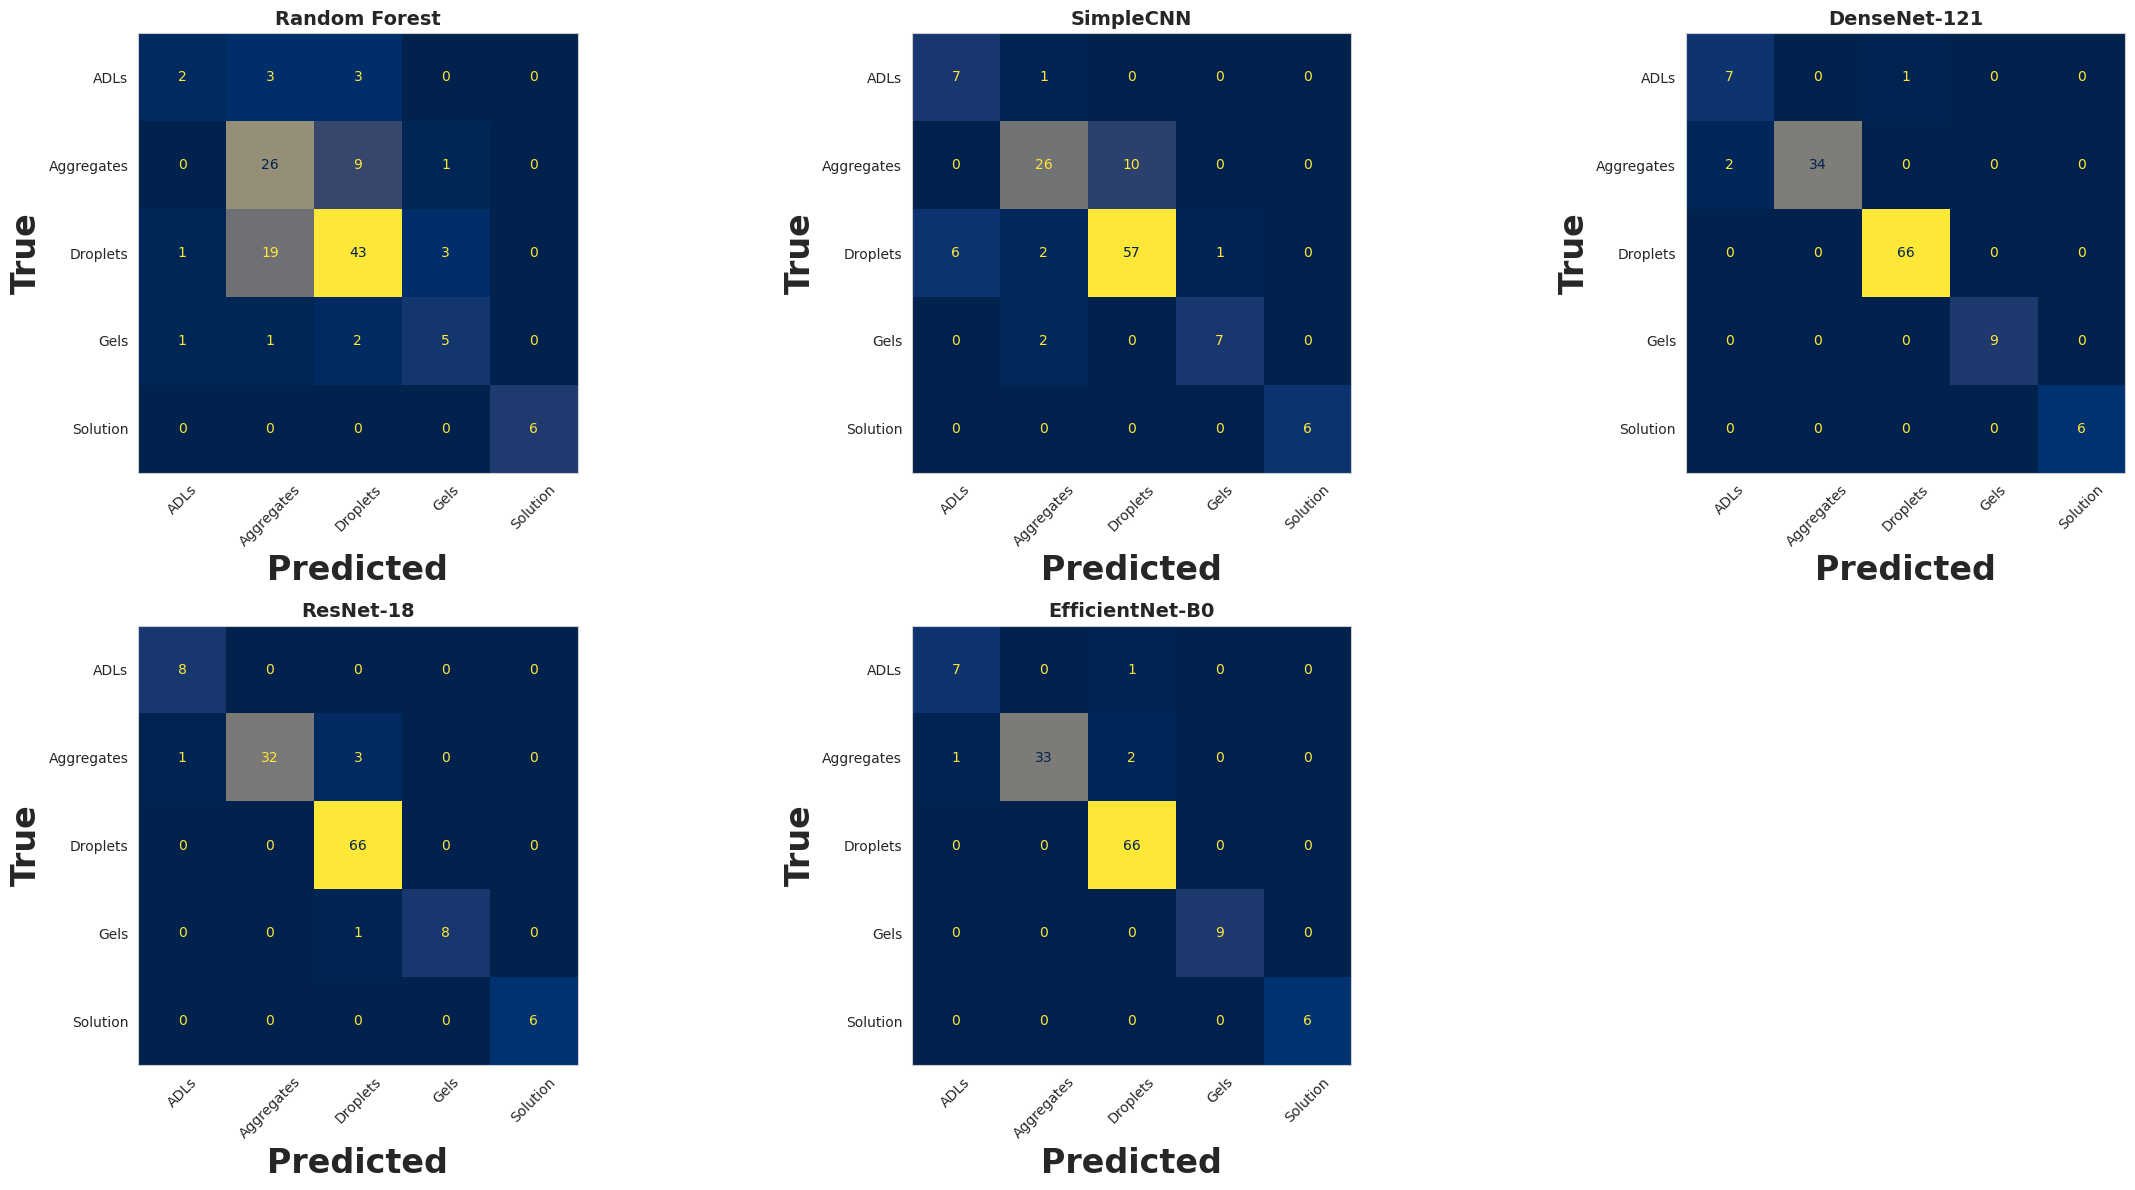

✅ Saved combined view: cm_all_models_combined.pdf

ALL DONE! 🎉


In [2]:
import numpy as np
import matplotlib.pyplot as plt
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay

# =========================
# Font settings (edit here)
# =========================
TICK_FONT_FAMILY = 'DejaVu Sans'   # e.g., 'Times New Roman', 'Arial'
TICK_FONT_SIZE   = 20
TICK_FONT_WEIGHT = 'bold'

CELL_FONT_FAMILY = 'DejaVu Sans'
CELL_FONT_SIZE   = 20
CELL_FONT_WEIGHT = 'semibold'

TITLE_FONT_SIZE   = 18
TITLE_FONT_WEIGHT = 'bold'

AXISLABEL_FONT_FAMILY = 'DejaVu Sans'
AXISLABEL_FONT_SIZE   = 24
AXISLABEL_FONT_WEIGHT = 'bold'
AXISLABEL_PAD         = 10  # spacing from axes

# ✅ FIXED: Use correct model names that match available_models dictionary
# These should match the keys in available_models from the previous code
models_for_cm = ['RandomForest', 'SimpleCNN', 'DenseNet', 'ResNet', 'EfficientNet']

# Display names for nice titles (optional - maps internal names to display names)
model_display_names = {
    'RandomForest': 'Random Forest',
    'SimpleCNN': 'SimpleCNN',
    'DenseNet': 'DenseNet-121',
    'ResNet': 'ResNet-18',
    'EfficientNet': 'EfficientNet-B0'
}

print("="*60)
print("GENERATING CONFUSION MATRICES")
print("="*60)

# Collect predictions
model_predictions = {}

for model_name in models_for_cm:
    if model_name in available_models:
        print(f"\nProcessing {model_name}...")
        
        # ✅ FIXED: Handle Random Forest separately with correct variable name
        if model_name == 'RandomForest':
            # Use X_test_rf (not X_test_scaled) - the properly prepared RF input
            y_pred = available_models[model_name].predict(rf_in)

            model_predictions[model_name] = y_pred
            print(f"  ✅ Got predictions for {model_name} (shape: {y_pred.shape})")
        
        # Neural network models - use probabilities from model_probs
        else:
            if model_name in model_probs:
                y_pred = np.argmax(model_probs[model_name], axis=1)
                model_predictions[model_name] = y_pred
                print(f"  ✅ Got predictions for {model_name} (shape: {y_pred.shape})")
            else:
                print(f"  ⚠️ No probabilities found for {model_name}")
    else:
        print(f"⚠️ {model_name} not found in available_models")
        print(f"   Available models: {list(available_models.keys())}")

print(f"\n{'='*60}")
print(f"Total models with predictions: {len(model_predictions)}")
print(f"Models: {list(model_predictions.keys())}")
print(f"{'='*60}\n")

# Verify we have the same number of predictions as test samples
if len(model_predictions) > 0:
    for model_name, preds in model_predictions.items():
        if len(preds) != len(y_test):
            print(f"⚠️ WARNING: {model_name} predictions ({len(preds)}) != test size ({len(y_test)})")
        else:
            print(f"✅ {model_name}: {len(preds)} predictions match test size")

# Ensure consistent class order
n_classes = len(CLASS_NAMES)
labels_in_order = list(range(n_classes))

print(f"\nClass labels: {CLASS_NAMES}")
print(f"Number of classes: {n_classes}\n")

# Create and save confusion matrices
saved_files = []

for model_name in models_for_cm:
    if model_name in model_predictions:
        print(f"Creating confusion matrix for {model_name}...")
        
        y_pred = model_predictions[model_name]
        
        # Compute confusion matrix
        cm = confusion_matrix(y_test, y_pred, labels=labels_in_order)
        
        # Calculate per-class accuracy
        per_class_acc = cm.diagonal() / cm.sum(axis=1)
        overall_acc = np.trace(cm) / np.sum(cm)
        
        print(f"  Overall Accuracy: {overall_acc:.4f}")
        print(f"  Per-class Accuracy:")
        for i, class_name in enumerate(CLASS_NAMES):
            print(f"    {class_name}: {per_class_acc[i]:.4f}")
        
        # Create figure
        fig, ax = plt.subplots(figsize=(10, 8))
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
        disp.plot(cmap='cividis', xticks_rotation=45, ax=ax, colorbar=False)
        
        # ✅ CRITICAL FIX: Turn off grid lines that cross through numbers
        ax.grid(False)

        # ----------------------------
        # Style tick labels (class names)
        # ----------------------------
        for lbl in ax.get_xticklabels():
            lbl.set_fontfamily(TICK_FONT_FAMILY)
            lbl.set_fontsize(TICK_FONT_SIZE)
            lbl.set_fontweight(TICK_FONT_WEIGHT)
        for lbl in ax.get_yticklabels():
            lbl.set_fontfamily(TICK_FONT_FAMILY)
            lbl.set_fontsize(TICK_FONT_SIZE)
            lbl.set_fontweight(TICK_FONT_WEIGHT)

        # ---------------------------------------
        # Style numeric annotations inside cells
        # ---------------------------------------
        if hasattr(disp, "text_") and disp.text_ is not None:
            for t in disp.text_.ravel():
                t.set_fontfamily(CELL_FONT_FAMILY)
                t.set_fontsize(CELL_FONT_SIZE)
                t.set_fontweight(CELL_FONT_WEIGHT)

        # ---------------------------------------
        # Style axis labels ("Predicted", "True")
        # ---------------------------------------
        ax.set_xlabel(
            "Predicted label",
            fontfamily=AXISLABEL_FONT_FAMILY,
            fontsize=AXISLABEL_FONT_SIZE,
            fontweight=AXISLABEL_FONT_WEIGHT,
            labelpad=AXISLABEL_PAD,
        )
        ax.set_ylabel(
            "True label",
            fontfamily=AXISLABEL_FONT_FAMILY,
            fontsize=AXISLABEL_FONT_SIZE,
            fontweight=AXISLABEL_FONT_WEIGHT,
            labelpad=AXISLABEL_PAD,
        )

        # Title - use display name if available
        display_name = model_display_names.get(model_name, model_name)
        ax.set_title(
            f"Confusion Matrix ({display_name})",
            fontsize=TITLE_FONT_SIZE,
            fontweight=TITLE_FONT_WEIGHT,
            pad=20
        )

        plt.tight_layout()

        # Save with consistent naming
        filename = f"cm_{model_name}.pdf"
        plt.savefig(filename, dpi=600, bbox_inches='tight')
        plt.show()  # Close to free memory
        
        saved_files.append(filename)
        print(f"  ✅ Saved: {filename}\n")
    else:
        print(f"⚠️ Skipping {model_name} - no predictions available\n")

# Final summary
print("="*60)
print("✅ CONFUSION MATRIX GENERATION COMPLETE")
print("="*60)
print(f"\n📁 Saved {len(saved_files)} confusion matrix files:")
for filename in saved_files:
    print(f"   - {filename}")

# Optional: Create a combined view of all confusion matrices
if len(model_predictions) > 1:
    print("\n" + "="*60)
    print("Creating combined confusion matrix comparison...")
    print("="*60)
    
    n_models = len(model_predictions)
    n_cols = min(3, n_models)
    n_rows = (n_models + n_cols - 1) // n_cols
    
    fig, axes = plt.subplots(n_rows, n_cols, figsize=(8*n_cols, 6*n_rows))
    if n_models == 1:
        axes = [axes]
    else:
        axes = axes.flatten() if n_rows > 1 else axes
    
    for idx, (model_name, y_pred) in enumerate(model_predictions.items()):
        cm = confusion_matrix(y_test, y_pred, labels=labels_in_order)
        
        ax = axes[idx] if n_models > 1 else axes[0]
        disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
        disp.plot(cmap='cividis', xticks_rotation=45, ax=ax, colorbar=False)
        
        # ✅ Turn off grid for combined view too
        ax.grid(False)
        
        display_name = model_display_names.get(model_name, model_name)
        ax.set_title(display_name, fontsize=14, fontweight='bold')
        
        # Simplify labels for combined view
        ax.set_xlabel('Predicted', fontsize=24, fontweight='bold')
        ax.set_ylabel('True', fontsize=24, fontweight='bold')
        
        # Smaller fonts for combined view
        for lbl in ax.get_xticklabels():
            lbl.set_fontsize(10)
        for lbl in ax.get_yticklabels():
            lbl.set_fontsize(10)
    
    # Hide empty subplots
    for idx in range(len(model_predictions), len(axes)):
        axes[idx].set_visible(False)
    
    plt.tight_layout()
    combined_filename = "cm_all_models_combined.pdf"
    plt.savefig(combined_filename, dpi=600, bbox_inches='tight')
    plt.show()
    
    print(f"✅ Saved combined view: {combined_filename}")

print("\n" + "="*60)
print("ALL DONE! 🎉")
print("="*60)

# OPtimization for CM

In [7]:
from scipy.optimize import minimize, differential_evolution
import numpy as np

# ============================================================
# ENSEMBLE WEIGHT OPTIMIZATION
# ============================================================

def calculate_ensemble_accuracy(weights, member_probs, y_true):
    """
    Calculate accuracy for given weights.
    Returns negative accuracy for minimization.
    """
    # Ensure weights sum to 1
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Weighted average of probabilities
    stacked = np.stack(member_probs, axis=0)  # M x N x C
    avg_probs = np.tensordot(weights, stacked, axes=(0, 0))  # N x C
    
    # Predictions
    y_pred = np.argmax(avg_probs, axis=1)
    
    # Calculate accuracy
    accuracy = np.mean(y_pred == y_true)
    
    # Return negative for minimization
    return -accuracy

# Method 1: Sequential Least Squares Programming (SLSQP)
print("🔍 Optimizing ensemble weights...")
print("\nMethod 1: SLSQP Optimization")

# Initial guess (equal weights)
initial_weights = np.ones(len(member_probs)) / len(member_probs)

# Constraints: weights sum to 1
constraints = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

# Bounds: weights between 0 and 1
bounds = [(0, 1) for _ in range(len(member_probs))]

# Optimize
result = minimize(
    calculate_ensemble_accuracy,
    initial_weights,
    args=(member_probs, y_test),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints,
    options={'maxiter': 1000}
)

optimal_weights_slsqp = result.x
optimal_accuracy_slsqp = -result.fun

print(f"Optimal weights: {optimal_weights_slsqp}")
print(f"Optimal accuracy: {optimal_accuracy_slsqp:.4f}")
print(f"Misclassified: {int((1 - optimal_accuracy_slsqp) * len(y_test))} / {len(y_test)}")

# Method 2: Differential Evolution (Global Optimization)
print("\nMethod 2: Differential Evolution (Global Search)")

# Bounds for each weight
bounds_de = [(0, 1) for _ in range(len(member_probs))]

def objective_with_constraint(weights):
    # Normalize to sum to 1
    weights = np.array(weights)
    weights = weights / weights.sum()
    return calculate_ensemble_accuracy(weights, member_probs, y_test)

result_de = differential_evolution(
    objective_with_constraint,
    bounds_de,
    seed=42,
    maxiter=300,
    popsize=15,
    atol=1e-7,
    tol=1e-7
)

optimal_weights_de = result_de.x
optimal_weights_de = optimal_weights_de / optimal_weights_de.sum()  # Normalize
optimal_accuracy_de = -result_de.fun

print(f"Optimal weights: {optimal_weights_de}")
print(f"Optimal accuracy: {optimal_accuracy_de:.4f}")
print(f"Misclassified: {int((1 - optimal_accuracy_de) * len(y_test))} / {len(y_test)}")

# Choose best result
if optimal_accuracy_de >= optimal_accuracy_slsqp:
    optimal_weights = optimal_weights_de
    optimal_accuracy = optimal_accuracy_de
    method_used = "Differential Evolution"
else:
    optimal_weights = optimal_weights_slsqp
    optimal_accuracy = optimal_accuracy_slsqp
    method_used = "SLSQP"

print(f"\n✅ Best method: {method_used}")
print(f"✅ Final optimal weights: {optimal_weights}")
print(f"✅ Final accuracy: {optimal_accuracy:.4f}")

🔍 Optimizing ensemble weights...

Method 1: SLSQP Optimization
Optimal weights: [0.33333333 0.33333333 0.33333333]
Optimal accuracy: 0.9680
Misclassified: 4 / 125

Method 2: Differential Evolution (Global Search)
Optimal weights: [0.68779109 0.21425981 0.0979491 ]
Optimal accuracy: 0.9840
Misclassified: 2 / 125

✅ Best method: Differential Evolution
✅ Final optimal weights: [0.68779109 0.21425981 0.0979491 ]
✅ Final accuracy: 0.9840


# OPtimization for probability

In [7]:
from scipy.optimize import minimize, differential_evolution, LinearConstraint
from sklearn.metrics import log_loss, accuracy_score

# ============================================================
# WEIGHT OPTIMIZATION - FOCUSING ON PROBABILITIES
# ============================================================

def ensemble_predict_with_weights(weights, member_probs_list):
    """
    Given weights and list of probability arrays, return weighted ensemble predictions
    """
    # Normalize weights
    weights = np.array(weights)
    weights = weights / weights.sum()
    
    # Weighted average
    stacked = np.stack(member_probs_list, axis=0)  # M x N x C
    avg_probs = np.tensordot(weights, stacked, axes=(0, 0))  # N x C
    
    # Renormalize
    row_sums = avg_probs.sum(axis=1, keepdims=True)
    row_sums[row_sums == 0] = 1.0
    avg_probs = avg_probs / row_sums
    
    return avg_probs

def objective_true_class_prob(weights, member_probs_list, y_true, focus_on_misclassified=False):
    """
    Maximize the probability assigned to the TRUE class
    (Minimize negative probability)
    """
    avg_probs = ensemble_predict_with_weights(weights, member_probs_list)
    
    # Get probability of the true class for each sample
    # avg_probs[i, y_true[i]] gives the probability of true class for sample i
    true_class_probs = avg_probs[np.arange(len(y_true)), y_true]
    
    if focus_on_misclassified:
        # Identify currently misclassified samples
        y_pred = np.argmax(avg_probs, axis=1)
        misclassified_mask = (y_pred != y_true)
        
        if misclassified_mask.sum() > 0:
            # Focus only on misclassified samples
            true_class_probs = true_class_probs[misclassified_mask]
        else:
            # If none misclassified, optimize all
            pass
    
    # Return negative mean probability (to minimize)
    return -np.mean(true_class_probs)

def objective_logloss(weights, member_probs_list, y_true):
    """
    Minimize cross-entropy loss (equivalent to maximizing log probability of true class)
    """
    avg_probs = ensemble_predict_with_weights(weights, member_probs_list)
    avg_probs = np.clip(avg_probs, 1e-15, 1 - 1e-15)
    return log_loss(y_true, avg_probs)

def objective_misclassified_prob(weights, member_probs_list, y_true):
    """
    Maximize probability of true class specifically for MISCLASSIFIED samples
    """
    avg_probs = ensemble_predict_with_weights(weights, member_probs_list)
    y_pred = np.argmax(avg_probs, axis=1)
    misclassified_mask = (y_pred != y_true)
    
    if misclassified_mask.sum() == 0:
        return 0.0  # Perfect accuracy, nothing to optimize
    
    # Get probabilities of true class for misclassified samples
    true_class_probs = avg_probs[np.arange(len(y_true)), y_true]
    misclassified_probs = true_class_probs[misclassified_mask]
    
    # Return negative mean probability
    return -np.mean(misclassified_probs)

# ============================================================
# ANALYZE INITIAL STATE
# ============================================================
print("\n" + "="*60)
print("OPTIMIZING ENSEMBLE WEIGHTS - PROBABILITY FOCUS")
print("="*60)

initial_weights = np.array([0.6, 0.15, 0.25])
bounds = [(0, 1) for _ in range(len(member_probs))]

# Get initial statistics
initial_probs = ensemble_predict_with_weights(initial_weights, member_probs)
initial_preds = np.argmax(initial_probs, axis=1)
initial_correct = (initial_preds == y_test)

# Probabilities assigned to true class
true_class_probs_initial = initial_probs[np.arange(len(y_test)), y_test]
misclassified_mask_initial = ~initial_correct

print(f"\n📊 Initial weights: {initial_weights}")
print(f"   Accuracy: {initial_correct.mean():.4f} ({initial_correct.sum()}/{len(y_test)})")
print(f"   Mean probability of true class (all): {true_class_probs_initial.mean():.4f}")
if misclassified_mask_initial.sum() > 0:
    print(f"   Mean probability of true class (misclassified only): "
          f"{true_class_probs_initial[misclassified_mask_initial].mean():.4f}")
    print(f"   Number of misclassified: {misclassified_mask_initial.sum()}")

# ============================================================
# METHOD 1: Maximize probability of true class (ALL samples)
# ============================================================
print(f"\n🎯 Method 1: Maximize true class probability (all samples)...")

constraints_minimize = {'type': 'eq', 'fun': lambda w: np.sum(w) - 1}

result_prob_all = minimize(
    objective_true_class_prob,
    initial_weights,
    args=(member_probs, y_test, False),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_minimize,
    options={'maxiter': 1000}
)

weights_prob_all = result_prob_all.x / result_prob_all.x.sum()
probs_prob_all = ensemble_predict_with_weights(weights_prob_all, member_probs)
preds_prob_all = np.argmax(probs_prob_all, axis=1)
true_class_probs_all = probs_prob_all[np.arange(len(y_test)), y_test]

print(f"✅ Optimized weights: {weights_prob_all}")
print(f"   Accuracy: {(preds_prob_all == y_test).mean():.4f}")
print(f"   Mean probability of true class: {true_class_probs_all.mean():.4f}")
print(f"   Improvement: {true_class_probs_all.mean() - true_class_probs_initial.mean():.6f}")

# ============================================================
# METHOD 2: Minimize log loss (equivalent but more stable)
# ============================================================
print(f"\n🎯 Method 2: Minimize log loss...")

result_logloss = minimize(
    objective_logloss,
    initial_weights,
    args=(member_probs, y_test),
    method='SLSQP',
    bounds=bounds,
    constraints=constraints_minimize,
    options={'maxiter': 1000}
)

weights_logloss = result_logloss.x / result_logloss.x.sum()
probs_logloss = ensemble_predict_with_weights(weights_logloss, member_probs)
preds_logloss = np.argmax(probs_logloss, axis=1)
true_class_probs_logloss = probs_logloss[np.arange(len(y_test)), y_test]

print(f"✅ Optimized weights: {weights_logloss}")
print(f"   Accuracy: {(preds_logloss == y_test).mean():.4f}")
print(f"   Mean probability of true class: {true_class_probs_logloss.mean():.4f}")
print(f"   Log loss: {result_logloss.fun:.6f}")

# ============================================================
# METHOD 3: Focus ONLY on misclassified samples
# ============================================================
if misclassified_mask_initial.sum() > 0:
    print(f"\n🎯 Method 3: Maximize probability for MISCLASSIFIED samples only...")
    
    result_misclass = minimize(
        objective_misclassified_prob,
        initial_weights,
        args=(member_probs, y_test),
        method='SLSQP',
        bounds=bounds,
        constraints=constraints_minimize,
        options={'maxiter': 1000}
    )
    
    weights_misclass = result_misclass.x / result_misclass.x.sum()
    probs_misclass = ensemble_predict_with_weights(weights_misclass, member_probs)
    preds_misclass = np.argmax(probs_misclass, axis=1)
    correct_misclass = (preds_misclass == y_test)
    true_class_probs_misclass = probs_misclass[np.arange(len(y_test)), y_test]
    
    # Check what happened to originally misclassified samples
    new_misclassified_mask = ~correct_misclass
    still_misclassified = misclassified_mask_initial & new_misclassified_mask
    
    print(f"✅ Optimized weights: {weights_misclass}")
    print(f"   Accuracy: {correct_misclass.mean():.4f}")
    print(f"   Mean probability of true class (all): {true_class_probs_misclass.mean():.4f}")
    
    if still_misclassified.sum() > 0:
        print(f"   Mean probability for still-misclassified: "
              f"{true_class_probs_misclass[still_misclassified].mean():.4f}")
        print(f"   Improvement for still-misclassified: "
              f"{true_class_probs_misclass[still_misclassified].mean() - true_class_probs_initial[misclassified_mask_initial].mean():.6f}")
    
    # Check if any were recovered
    recovered = misclassified_mask_initial & correct_misclass
    print(f"   Recovered samples: {recovered.sum()}")

# ============================================================
# METHOD 4: Differential Evolution on log loss
# ============================================================
print(f"\n🎯 Method 4: Differential Evolution (log loss)...")

n_models = len(member_probs)
linear_constraint = LinearConstraint(np.ones(n_models), 1, 1)

result_de = differential_evolution(
    objective_logloss,
    bounds=bounds,
    args=(member_probs, y_test),
    constraints=linear_constraint,
    seed=42,
    maxiter=200,
    popsize=15,
    atol=1e-7,
    tol=1e-7,
    workers=1
)

weights_de = result_de.x / result_de.x.sum()
probs_de = ensemble_predict_with_weights(weights_de, member_probs)
preds_de = np.argmax(probs_de, axis=1)
true_class_probs_de = probs_de[np.arange(len(y_test)), y_test]

print(f"✅ Optimized weights: {weights_de}")
print(f"   Accuracy: {(preds_de == y_test).mean():.4f}")
print(f"   Mean probability of true class: {true_class_probs_de.mean():.4f}")
print(f"   Log loss: {result_de.fun:.6f}")

# ============================================================
# COMPARISON
# ============================================================
print(f"\n" + "="*60)
print("COMPARISON - PROBABILITY OF TRUE CLASS")
print("="*60)

results = [
    ("Original", initial_weights, 
     initial_correct.mean(), 
     true_class_probs_initial.mean()),
    ("Max True Class Prob (All)", weights_prob_all, 
     (preds_prob_all == y_test).mean(), 
     true_class_probs_all.mean()),
    ("Min Log Loss", weights_logloss, 
     (preds_logloss == y_test).mean(), 
     true_class_probs_logloss.mean()),
]

if misclassified_mask_initial.sum() > 0:
    results.append(
        ("Max Prob (Misclassified)", weights_misclass, 
         correct_misclass.mean(), 
         true_class_probs_misclass.mean())
    )

results.append(
    ("Differential Evolution", weights_de, 
     (preds_de == y_test).mean(), 
     true_class_probs_de.mean())
)

print(f"\n{'Method':<30} {'Accuracy':<12} {'Mean P(true)':<15} {'Weights'}")
print("="*85)
for method, weights, acc, mean_prob in results:
    weight_str = f"[{weights[0]:.3f}, {weights[1]:.3f}, {weights[2]:.3f}]"
    print(f"{method:<30} {acc:<12.4f} {mean_prob:<15.6f} {weight_str}")

# Find best based on mean probability of true class
best_idx = np.argmax([r[3] for r in results])
best_method, best_weights, best_acc, best_prob = results[best_idx]

print(f"\n🏆 BEST METHOD: {best_method}")
print(f"   Weights: {best_weights}")
print(f"   Accuracy: {best_acc:.4f}")
print(f"   Mean P(true class): {best_prob:.6f}")
print(f"   Improvement in P(true): {best_prob - true_class_probs_initial.mean():.6f}")

# ============================================================
# DETAILED ANALYSIS OF MISCLASSIFIED SAMPLES
# ============================================================
if misclassified_mask_initial.sum() > 0:
    print(f"\n" + "="*60)
    print("DETAILED ANALYSIS - ORIGINALLY MISCLASSIFIED SAMPLES")
    print("="*60)
    
    best_probs = ensemble_predict_with_weights(best_weights, member_probs)
    best_preds = np.argmax(best_probs, axis=1)
    best_true_class_probs = best_probs[np.arange(len(y_test)), y_test]
    
    # Focus on originally misclassified
    orig_mis_indices = np.where(misclassified_mask_initial)[0]
    
    print(f"\nOriginally misclassified: {len(orig_mis_indices)} samples")
    print(f"\nProbability changes:")
    print(f"  Before: {true_class_probs_initial[misclassified_mask_initial].mean():.6f}")
    print(f"  After:  {best_true_class_probs[misclassified_mask_initial].mean():.6f}")
    print(f"  Change: +{best_true_class_probs[misclassified_mask_initial].mean() - true_class_probs_initial[misclassified_mask_initial].mean():.6f}")
    
    # Check recovery
    recovered = misclassified_mask_initial & (best_preds == y_test)
    still_wrong = misclassified_mask_initial & (best_preds != y_test)
    
    print(f"\nRecovered (now correct): {recovered.sum()}")
    print(f"Still misclassified: {still_wrong.sum()}")
    
    if still_wrong.sum() > 0:
        print(f"\nFor samples still misclassified:")
        print(f"  Probability of true class increased by: "
              f"+{best_true_class_probs[still_wrong].mean() - true_class_probs_initial[still_wrong].mean():.6f}")

# Final weights to use
weights = best_weights
print(f"\n" + "="*60)
print("FINAL WEIGHTS TO USE")
print("="*60)
print(f"weights = np.array([{best_weights[0]:.6f}, {best_weights[1]:.6f}, {best_weights[2]:.6f}])")


OPTIMIZING ENSEMBLE WEIGHTS - PROBABILITY FOCUS

📊 Initial weights: [0.6  0.15 0.25]
   Accuracy: 0.9840 (123/125)
   Mean probability of true class (all): 0.9603
   Mean probability of true class (misclassified only): 0.0711
   Number of misclassified: 2

🎯 Method 1: Maximize true class probability (all samples)...
✅ Optimized weights: [1.00000000e+00 2.28983499e-16 2.22044605e-16]
   Accuracy: 0.9760
   Mean probability of true class: 0.9708
   Improvement: 0.010518

🎯 Method 2: Minimize log loss...
✅ Optimized weights: [8.64983067e-01 1.35016933e-01 2.22478286e-16]
   Accuracy: 0.9840
   Mean probability of true class: 0.9665
   Log loss: 0.062303

🎯 Method 3: Maximize probability for MISCLASSIFIED samples only...
✅ Optimized weights: [0.49061788 0.50873137 0.00065075]
   Accuracy: 0.9600
   Mean probability of true class (all): 0.9545
   Mean probability for still-misclassified: 0.1343
   Improvement for still-misclassified: 0.063216
   Recovered samples: 0

🎯 Method 4: Differenti


================ ENSEMBLE (avg probs) ================
Members used: ['DenseNet', 'ResNet', 'EfficientNet']
Overall Accuracy: 0.9840
Per-class Accuracy:
  ADLs: 0.8750
  Aggregates: 0.9722
  Droplets: 1.0000
  Gels: 1.0000
  Solution: 1.0000


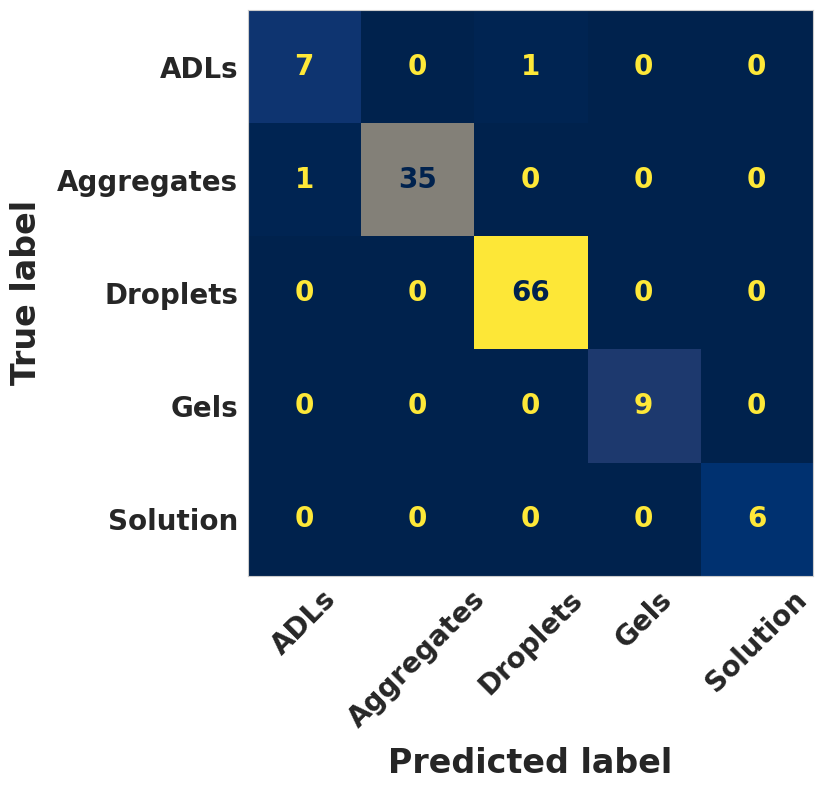

  ✅ Saved: cm_ensemble_avg_counts.pdf


In [9]:
# ============================================================
# ENSEMBLE (Average probabilities of DenseNet/ResNet/EfficientNet)
# ============================================================

ensemble_members = ['DenseNet', 'ResNet', 'EfficientNet']  # change/order as you like

# Gather available member prob arrays (N x C)
member_probs = []
missing = []
for k in ensemble_members:
    if k in model_probs:
        member_probs.append(model_probs[k])
    else:
        missing.append(k)

if not member_probs:
    raise RuntimeError(f"No ensemble members found in model_probs. Missing: {missing}")

if missing:
    print(f"⚠️ Ensemble missing probabilities for: {missing}. Proceeding with available: "
          f"{[m for m in ensemble_members if m not in missing]}")

# Stack and average -> (num_models_used, N, C) -> (N, C)
#stacked = np.stack(member_probs, axis=0)  # shape: M x N x C
#avg_probs = stacked.mean(axis=0)          # shape: N x C



weights = np.array([0.68779109, 0.21425981, 0.0979491 ], dtype=float)  # example for [DenseNet, ResNet, EfficientNet]
weights = weights[[i for i, k in enumerate(ensemble_members) if k not in missing]]
weights = weights / weights.sum()
stacked = np.stack(member_probs, axis=0)  # M x N x C
avg_probs = np.tensordot(weights, stacked, axes=(0, 0))  # N x C



# (Optional but safe) Renormalize per sample in case of tiny drift
row_sums = avg_probs.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
avg_probs = avg_probs / row_sums

# Final ensemble predictions
y_pred_ens = np.argmax(avg_probs, axis=1)

# ------------------------------------------------------------
# Confusion matrix + metrics
# ------------------------------------------------------------
n_classes = len(CLASS_NAMES)
labels_in_order = list(range(n_classes))
cm_ens = confusion_matrix(y_test, y_pred_ens, labels=labels_in_order)

row_totals = cm_ens.sum(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    per_class_acc = np.divide(cm_ens.diagonal(), row_totals, out=np.zeros_like(row_totals, dtype=float), where=row_totals!=0)
overall_acc = (np.trace(cm_ens) / np.sum(cm_ens)) if np.sum(cm_ens) > 0 else 0.0

print("\n================ ENSEMBLE (avg probs) ================")
print(f"Members used: {[m for m in ensemble_members if m not in missing]}")
print(f"Overall Accuracy: {overall_acc:.4f}")
print("Per-class Accuracy:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {per_class_acc[i]:.4f}")

# ------------------------------------------------------------
# Plot helper to match your styling
# ------------------------------------------------------------
def plot_cm(cm, title, filename, normalize=False):
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fmt = ".2f" if normalize else "d"
    disp.plot(cmap='cividis', xticks_rotation=45, ax=ax, colorbar=False, values_format=fmt)

    # Turn off grid lines
    ax.grid(False)

    # Style tick labels
    for lbl in ax.get_xticklabels():
        lbl.set_fontfamily(TICK_FONT_FAMILY)
        lbl.set_fontsize(TICK_FONT_SIZE)
        lbl.set_fontweight(TICK_FONT_WEIGHT)
    for lbl in ax.get_yticklabels():
        lbl.set_fontfamily(TICK_FONT_FAMILY)
        lbl.set_fontsize(TICK_FONT_SIZE)
        lbl.set_fontweight(TICK_FONT_WEIGHT)

    # Style cell texts (if present)
    if hasattr(disp, "text_") and disp.text_ is not None:
        for t in disp.text_.ravel():
            t.set_fontfamily(CELL_FONT_FAMILY)
            t.set_fontsize(CELL_FONT_SIZE)
            t.set_fontweight(CELL_FONT_WEIGHT)

    # Axis labels
    # ax.set_xlabel("Predicted label",
    #               fontfamily=AXISLABEL_FONT_FAMILY, fontsize=AXISLABEL_FONT_SIZE,
    #               fontweight=AXISLABEL_FONT_WEIGHT, labelpad=AXISLABEL_PAD)
    # ax.set_ylabel("True label",
    #               fontfamily=AXISLABEL_FONT_FAMILY, fontsize=AXISLABEL_FONT_SIZE,
    #               fontweight=AXISLABEL_FONT_WEIGHT, labelpad=AXISLABEL_PAD)

    
    
    ax.set_xlabel(
            "Predicted label",
            fontfamily=AXISLABEL_FONT_FAMILY,
            fontsize=AXISLABEL_FONT_SIZE,
            fontweight=AXISLABEL_FONT_WEIGHT,
            labelpad=AXISLABEL_PAD)
    
    ax.set_ylabel(
            "True label",
            fontfamily=AXISLABEL_FONT_FAMILY,
            fontsize=AXISLABEL_FONT_SIZE,
            fontweight=AXISLABEL_FONT_WEIGHT,
            labelpad=AXISLABEL_PAD )

    
    
    # ax.set_title(title, fontsize=TITLE_FONT_SIZE, fontweight=TITLE_FONT_WEIGHT, pad=20)
    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.show(fig)
    print(f"  ✅ Saved: {filename}")

# Save count CM
title_counts = "Confusion Matrix (Ensemble: Avg of DenseNet/ResNet/EfficientNet)"
file_counts  = "cm_ensemble_avg_counts.pdf"
plot_cm(cm_ens, title_counts, file_counts, normalize=False)



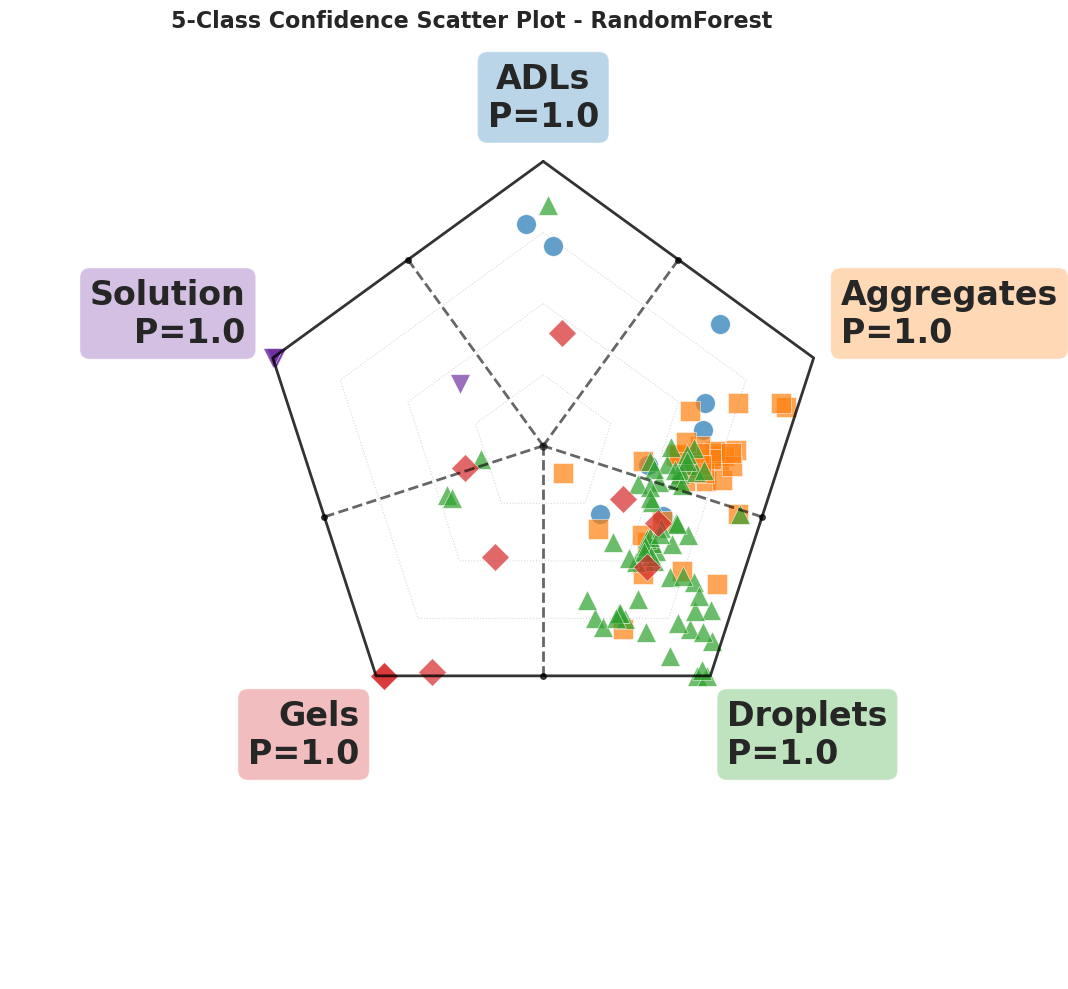

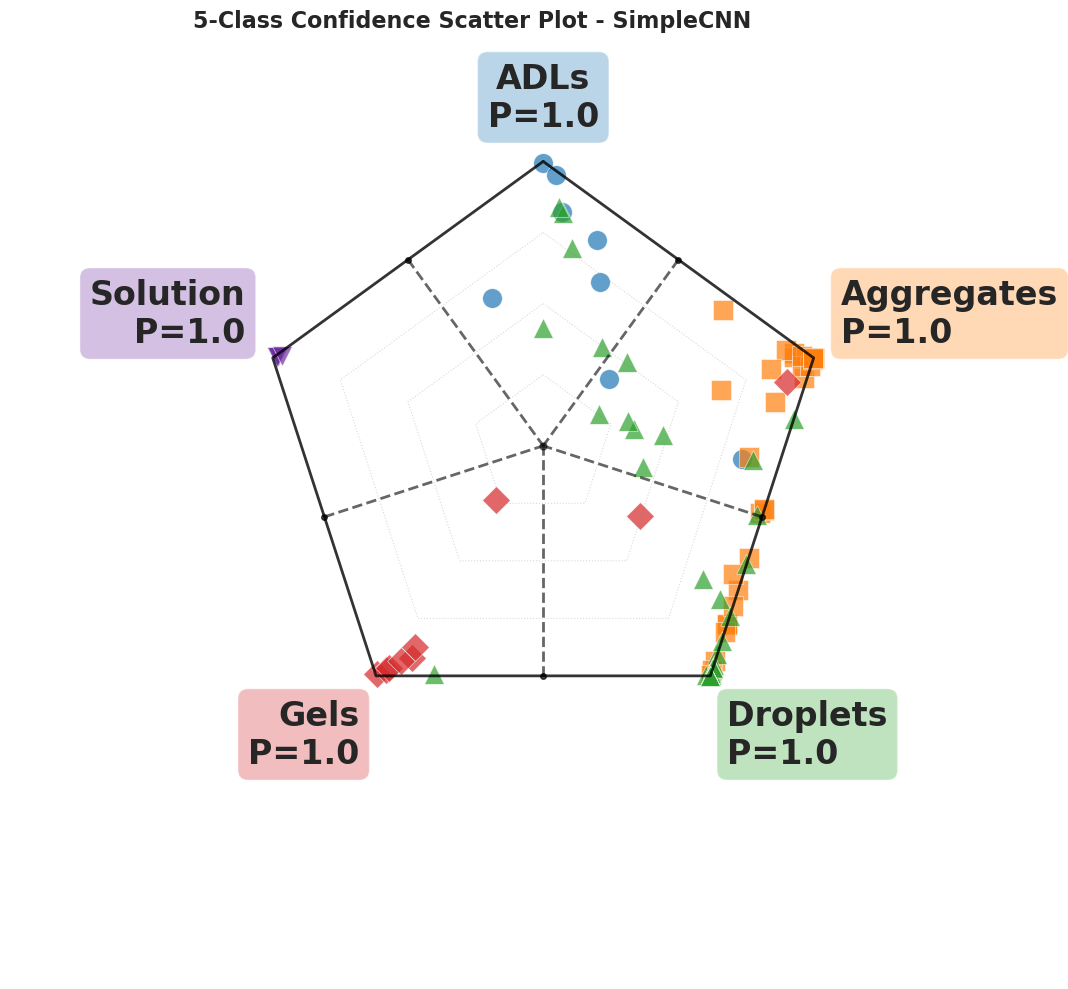

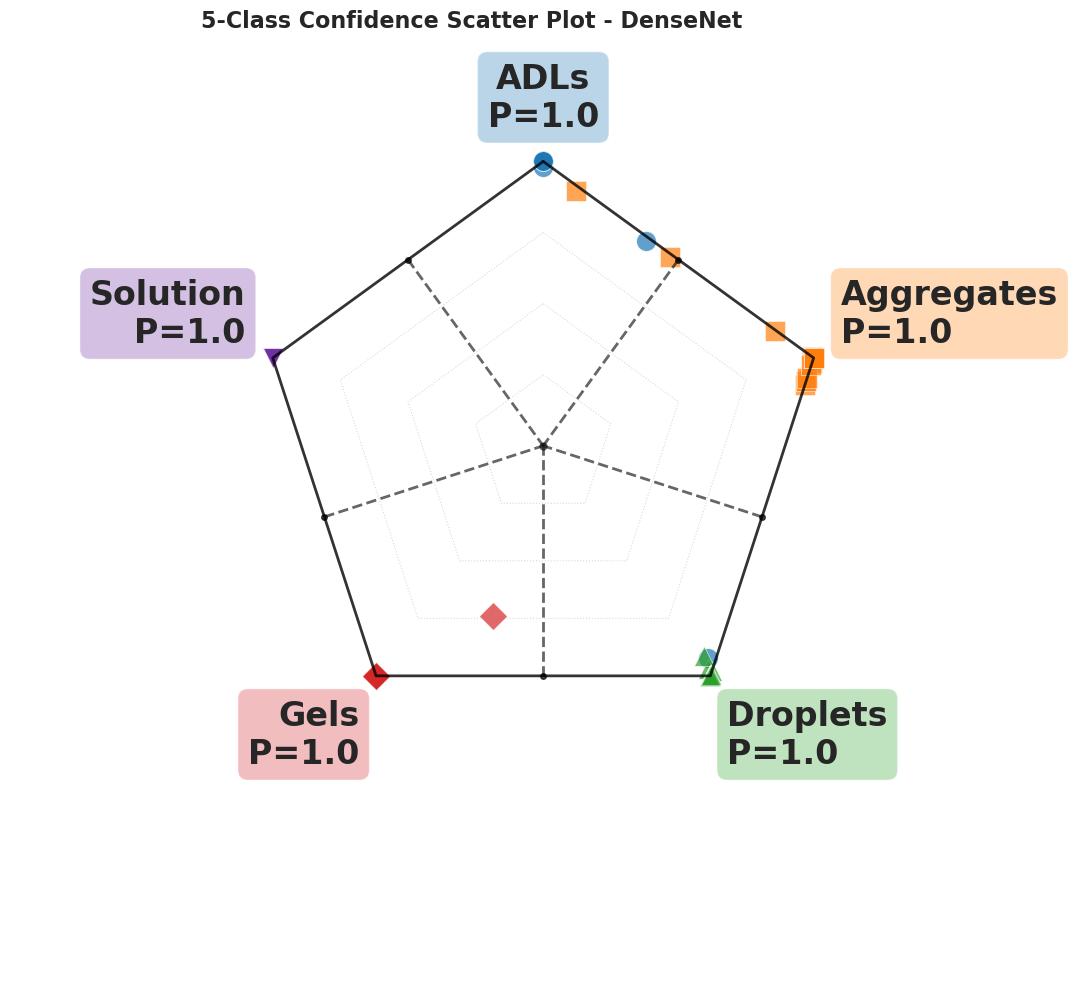

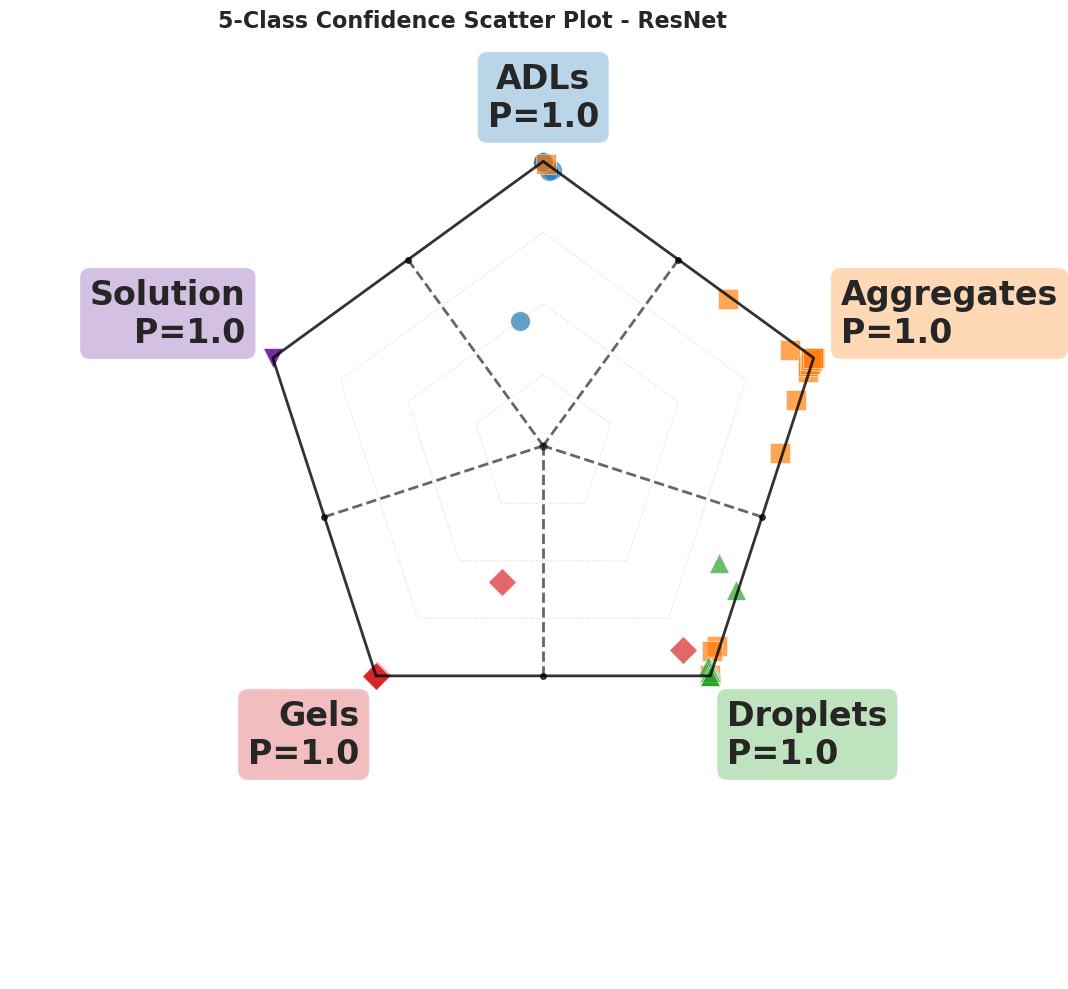

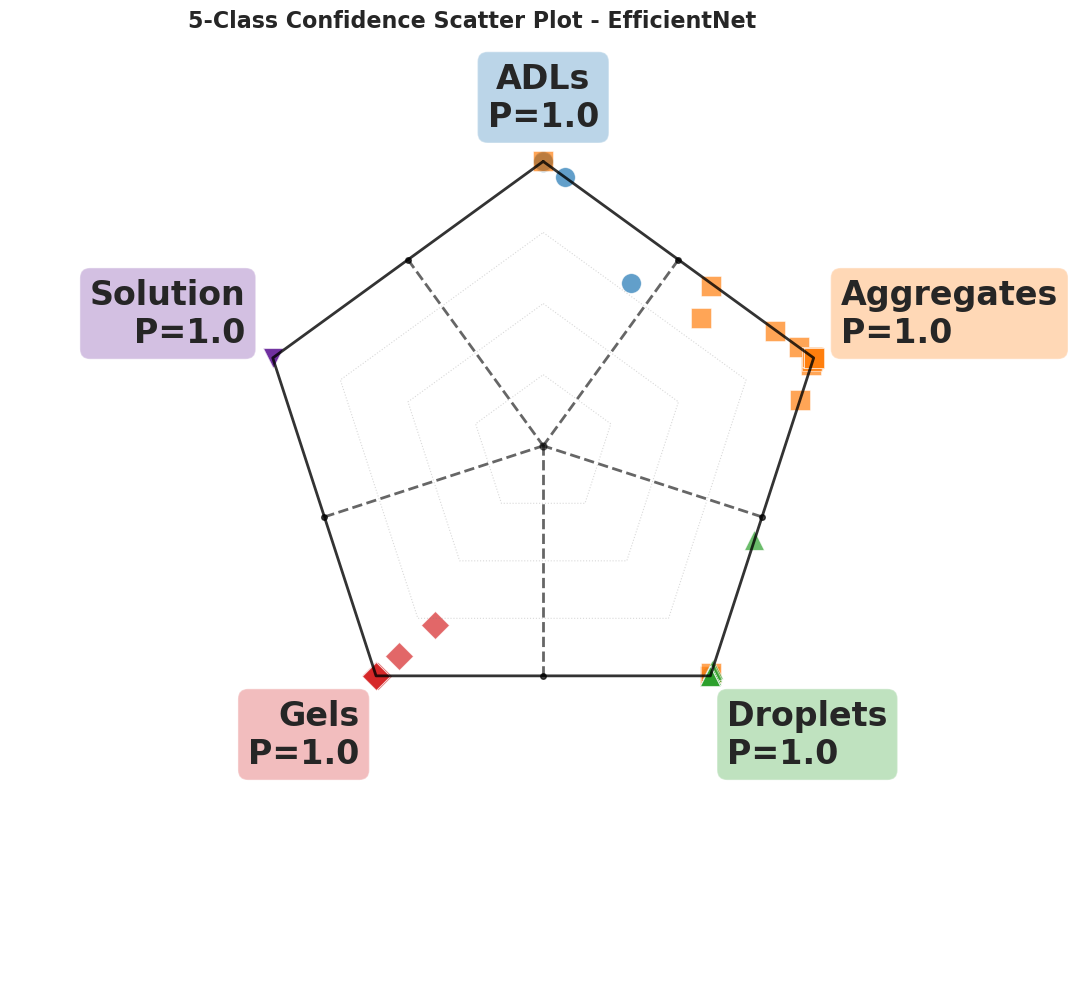

✅ All pentagonal confidence plots generated!


In [46]:
import matplotlib.pyplot as plt
import numpy as np

def create_pentagonal_plot(model_probs, y_test, class_names, model_name='Model'):
    """
    Creates a pentagonal confidence plot for 5-class classification.
    Each corner represents one class with probability = 1.0
    """
    probs = model_probs[model_name]
    
    # Pentagon coordinate transformation using barycentric coordinates
    # Pentagon vertices arranged in a circle, centered at (0.5, 0.5)
    # Starting from top and going clockwise
    
    radius = 0.4
    center_x, center_y = 0.5, 0.5
    
    # Calculate pentagon vertices (5 corners, evenly spaced at 72° intervals)
    # Start from top (angle = 90°) and go clockwise
    angles = [90, 18, -54, -126, -198]  # degrees, starting from top
    vertices = []
    for angle in angles:
        rad = np.radians(angle)
        x = center_x + radius * np.cos(rad)
        y = center_y + radius * np.sin(rad)
        vertices.append((x, y))
    
    # Barycentric coordinate transformation for 5 classes
    x_coords = sum(probs[:, i] * vertices[i][0] for i in range(5))
    y_coords = sum(probs[:, i] * vertices[i][1] for i in range(5))
    
    # Pentagon corner positions for each pure class (probability = 1.0)
    corners = {
        0: vertices[0],  # Top
        1: vertices[1],  # Top-right
        2: vertices[2],  # Bottom-right
        3: vertices[3],  # Bottom-left
        4: vertices[4]   # Top-left
    }
    
    # Create the plot
    fig, ax = plt.subplots(figsize=(12, 10))
    
    # Colors and markers for each true class (5 classes)
    colors = ['#1f77b4', '#ff7f0e', '#2ca02c', '#d62728', '#7030A0']  # blue, orange, green, red, purple
    markers = ['o', 's', '^', 'D', 'v']  # circle, square, triangle-up, diamond, triangle-down
    
    # Plot points colored by true class
    for class_idx in range(len(class_names)):
        mask = (y_test == class_idx)
        if np.sum(mask) > 0:
            ax.scatter(x_coords[mask], y_coords[mask], 
                      c=colors[class_idx], 
                      marker=markers[class_idx],
                      label=f'{class_names[class_idx]} (n={np.sum(mask)})',
                      alpha=0.7, s=200, edgecolors='white', linewidth=0.5)
    
    # Draw the pentagon boundary
    boundary_x = [v[0] for v in vertices] + [vertices[0][0]]
    boundary_y = [v[1] for v in vertices] + [vertices[0][1]]
    ax.plot(boundary_x, boundary_y, 'k-', linewidth=2, alpha=0.8)
    
    # Calculate midpoints of each side of the pentagon
    side_midpoints = []
    for i in range(5):
        v1 = vertices[i]
        v2 = vertices[(i + 1) % 5]  # Next vertex (wrap around)
        midpoint_x = (v1[0] + v2[0]) / 2
        midpoint_y = (v1[1] + v2[1]) / 2
        side_midpoints.append((midpoint_x, midpoint_y))
    
    # Draw decision boundaries from side midpoints to center
    for midpoint in side_midpoints:
        ax.plot([midpoint[0], center_x], [midpoint[1], center_y], 
                'k--', alpha=0.6, linewidth=2)
    
    # Mark the side midpoints (optional - for clarity)
    for midpoint in side_midpoints:
        ax.plot(midpoint[0], midpoint[1], 'ko', markersize=4, alpha=0.7)
    
    # Add corner labels with probability annotations
    label_offset = 0.04
    for class_idx, (x, y) in corners.items():
        # Calculate direction from center to vertex for label placement
        dx = x - center_x
        dy = y - center_y
        norm = np.sqrt(dx**2 + dy**2)
        dx_norm = dx / norm
        dy_norm = dy / norm
        
        # Place label outside the pentagon
        label_x = x + dx_norm * label_offset
        label_y = y + dy_norm * label_offset
        
        # Determine text alignment based on position
        if dx_norm > 0.3:
            ha = 'left'
        elif dx_norm < -0.3:
            ha = 'right'
        else:
            ha = 'center'
            
        if dy_norm > 0.3:
            va = 'bottom'
        elif dy_norm < -0.3:
            va = 'top'
        else:
            va = 'center'
        
        ax.text(label_x, label_y, f'{class_names[class_idx]}\nP=1.0', 
                fontsize=24, ha=ha, va=va, fontweight='bold',
                bbox=dict(boxstyle="round,pad=0.3", facecolor=colors[class_idx], alpha=0.3))
    
    # Add probability grid lines (concentric pentagons)
    for scale in [0.25, 0.5, 0.75]:
        scaled_vertices = [(center_x + scale * (v[0] - center_x), 
                           center_y + scale * (v[1] - center_y)) for v in vertices]
        grid_x = [v[0] for v in scaled_vertices] + [scaled_vertices[0][0]]
        grid_y = [v[1] for v in scaled_vertices] + [scaled_vertices[0][1]]
        ax.plot(grid_x, grid_y, ':', alpha=0.3, color='gray', linewidth=0.8)
    
    # Mark the center point
    ax.plot(center_x, center_y, 'ko', markersize=5, alpha=0.5)
    
    # Set limits and aspect
    ax.set_xlim(-0.25, 1.05)
    ax.set_ylim(-0.25, 1.05)
    ax.set_aspect('equal')
    
    # Hide all axis elements
    ax.set_xticks([])
    ax.set_yticks([])
    ax.spines['top'].set_visible(False)
    ax.spines['right'].set_visible(False)
    ax.spines['bottom'].set_visible(False)
    ax.spines['left'].set_visible(False)
    
    # Legend
    # legend = ax.legend(
    #     bbox_to_anchor=(1.05, 0.85),
    #     loc='upper left',
    #     frameon=True,
    #     fancybox=True,
    #     shadow=True,
    #     fontsize=22,
    #     labelspacing=1.2,
    #     borderpad=1.2,
    #     handlelength=2.5,
    #     handletextpad=1.2)
    
    # legend.get_frame().set_facecolor('white')
    
    # legend.get_frame().set_alpha(1.0)
    
    # Title
    ax.set_title(f'5-Class Confidence Scatter Plot - {model_name}', 
                 fontsize=16, fontweight='bold', pad=20)
    
    plt.tight_layout()
    plt.savefig(f'pentagonal_plot_{model_name.replace(" ", "_")}.pdf', 
                dpi=600, bbox_inches='tight')
    plt.show()

# Generate plots for all models
for model_name in model_probs.keys():
    create_pentagonal_plot(model_probs, y_test, CLASS_NAMES, model_name)
    
print("✅ All pentagonal confidence plots generated!")


================ ENSEMBLE (weighted avg) ================
Members used: ['DenseNet', 'ResNet', 'EfficientNet']
Weights used: [0.6, 0.15, 0.25]
Overall Accuracy: 0.9840
Per-class Accuracy:
  ADLs: 0.8750
  Aggregates: 0.9722
  Droplets: 1.0000
  Gels: 1.0000
  Solution: 1.0000
  ✅ Saved: cm_ensemble_weighted_counts.pdf
  ✅ Saved: cm_ensemble_weighted_normalized.pdf


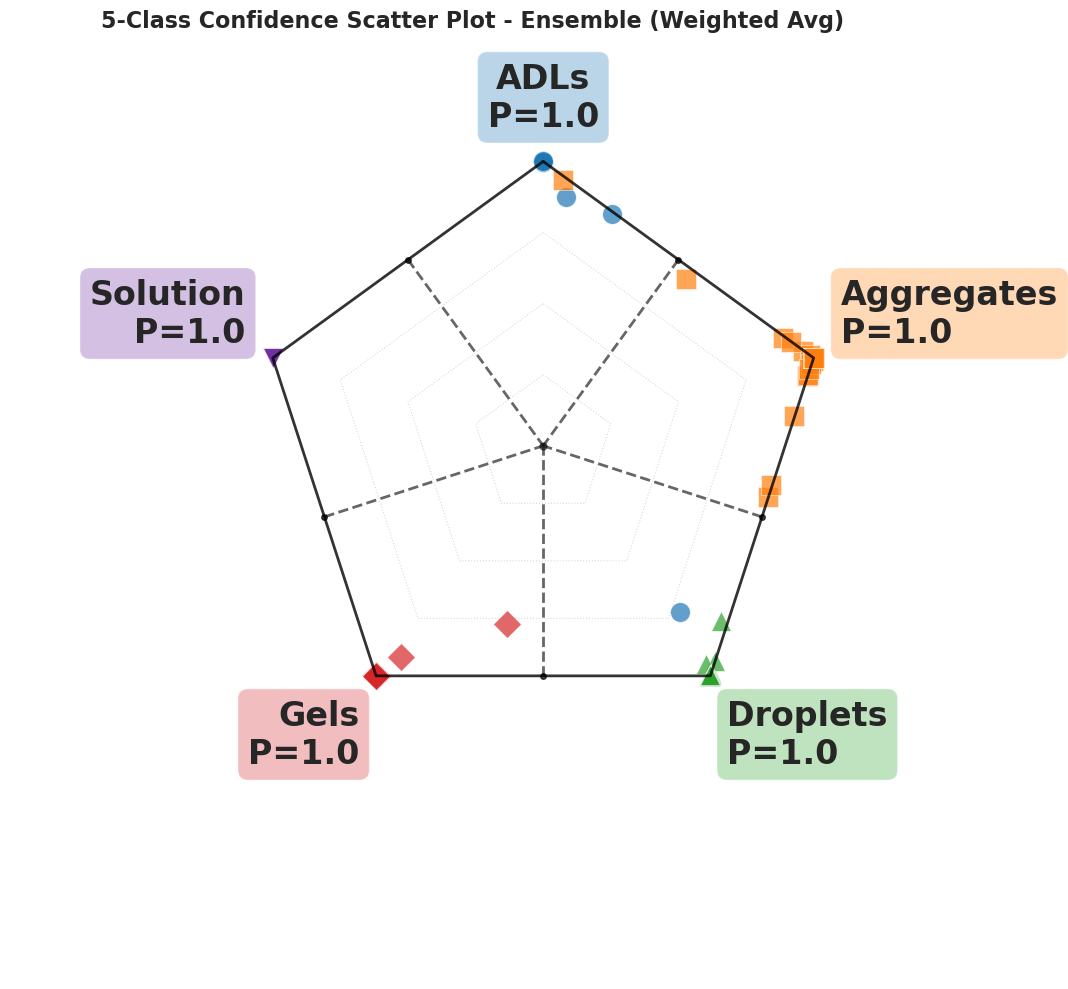

In [47]:
# ===============================
# Weighted probability ensemble
# ===============================
import numpy as np
from sklearn.metrics import confusion_matrix, ConfusionMatrixDisplay
import matplotlib.pyplot as plt

# ---- choose weights in the order [DenseNet, ResNet, EfficientNet]
weights = np.array([0.6, 0.15, 0.25], dtype=float)

ensemble_members = ['DenseNet', 'ResNet', 'EfficientNet']
available = [m for m in ensemble_members if m in model_probs]

if not available:
    raise RuntimeError("No ensemble members found in model_probs. "
                       f"Expected any of {ensemble_members}, got keys={list(model_probs.keys())}")

# Filter weights to available members (preserve original order)
sel = [ensemble_members.index(m) for m in available]
w = weights[sel].astype(float)
w = w / w.sum()

# Stack probs for available members: shape (M, N, C)
stacked = np.stack([model_probs[m] for m in available], axis=0)

# Weighted average over models -> (N, C)
avg_probs = np.tensordot(w, stacked, axes=(0, 0))  # (N, C)

# Renormalize row-wise (safety)
row_sums = avg_probs.sum(axis=1, keepdims=True)
row_sums[row_sums == 0] = 1.0
avg_probs = avg_probs / row_sums

# Final predictions
y_pred_ens = np.argmax(avg_probs, axis=1)

# ===============================
# Confusion matrix (counts + norm)
# ===============================
n_classes = len(CLASS_NAMES)
labels_in_order = list(range(n_classes))
cm_ens = confusion_matrix(y_test, y_pred_ens, labels=labels_in_order)

row_totals = cm_ens.sum(axis=1)
with np.errstate(divide='ignore', invalid='ignore'):
    per_class_acc = np.divide(cm_ens.diagonal(), row_totals, out=np.zeros_like(row_totals, dtype=float), where=row_totals!=0)
overall_acc = (np.trace(cm_ens) / np.sum(cm_ens)) if np.sum(cm_ens) > 0 else 0.0

print("\n================ ENSEMBLE (weighted avg) ================")
print(f"Members used: {available}")
print(f"Weights used: {w.tolist()}")
print(f"Overall Accuracy: {overall_acc:.4f}")
print("Per-class Accuracy:")
for i, name in enumerate(CLASS_NAMES):
    print(f"  {name}: {per_class_acc[i]:.4f}")

def plot_cm(cm, title, filename, normalize=False):
    fig, ax = plt.subplots(figsize=(10, 8))
    disp = ConfusionMatrixDisplay(confusion_matrix=cm, display_labels=CLASS_NAMES)
    fmt = ".2f" if normalize else "d"
    disp.plot(cmap='cividis', xticks_rotation=45, ax=ax, colorbar=False, values_format=fmt)
    ax.grid(False)

    # Tick styling (reuse your globals if defined)
    for lbl in ax.get_xticklabels():
        lbl.set_fontfamily(TICK_FONT_FAMILY); lbl.set_fontsize(TICK_FONT_SIZE); lbl.set_fontweight(TICK_FONT_WEIGHT)
    for lbl in ax.get_yticklabels():
        lbl.set_fontfamily(TICK_FONT_FAMILY); lbl.set_fontsize(TICK_FONT_SIZE); lbl.set_fontweight(TICK_FONT_WEIGHT)

    if hasattr(disp, "text_") and disp.text_ is not None:
        for t in disp.text_.ravel():
            t.set_fontfamily(CELL_FONT_FAMILY); t.set_fontsize(CELL_FONT_SIZE); t.set_fontweight(CELL_FONT_WEIGHT)

    ax.set_xlabel("Predicted label",
                  fontfamily=AXISLABEL_FONT_FAMILY, fontsize=AXISLABEL_FONT_SIZE,
                  fontweight=AXISLABEL_FONT_WEIGHT, labelpad=AXISLABEL_PAD)
    ax.set_ylabel("True label",
                  fontfamily=AXISLABEL_FONT_FAMILY, fontsize=AXISLABEL_FONT_SIZE,
                  fontweight=AXISLABEL_FONT_WEIGHT, labelpad=AXISLABEL_PAD)
    ax.set_title(title, fontsize=TITLE_FONT_SIZE, fontweight=TITLE_FONT_WEIGHT, pad=20)

    plt.tight_layout()
    plt.savefig(filename, dpi=600, bbox_inches='tight')
    plt.close(fig)
    print(f"  ✅ Saved: {filename}")

# Save count CM
title_counts = "Confusion Matrix (Ensemble: Weighted Avg of D121/R18/Eff-B0)"
file_counts  = "cm_ensemble_weighted_counts.pdf"
plot_cm(cm_ens, title_counts, file_counts, normalize=False)

# Save normalized-by-true CM
norm_ens = cm_ens.astype(float) / row_totals[:, None].clip(min=1)
title_norm = "Confusion Matrix (Normalized, Ensemble Weighted Avg)"
file_norm  = "cm_ensemble_weighted_normalized.pdf"
plot_cm(norm_ens, title_norm, file_norm, normalize=True)

# =======================================
# Pentagonal scatter for the ENSEMBLE
# =======================================
# Reuse your existing function by passing a one-off dict
ensemble_name = "Ensemble (Weighted Avg)"
tmp_probs = {ensemble_name: avg_probs}
create_pentagonal_plot(tmp_probs, y_test, CLASS_NAMES, model_name=ensemble_name)
